### File Structure

There are many files here which may look overwhelming. 

This notebook should contain all information you need in order to execute and use DiffLogic, though you may wish to modify and understand the remaining files.

For that, I have included below a brief description of each folder/file and how they should be used:

```.
├── config/
│   ├── MNIST_hyperparameters.csv         # Comma separated valued (CSV) excel sheet where you may set # of layers and hyperparameters for your model
│   ├── csv_to_yaml_mnist.ipynb           # Jupyter Notebook for converting the CSV into a YAML configuration file.
│   ├── mnist_config.yaml                 # Configuration file for the 180 different DiffLogic model architectures
├── data-mnist/
│   ├── MNIST/                            # MNIST dataset files (e.g., training and test sets)
├── trained_models/
│   ├── *.pth                             # Trained DiffLogic model files saved as .pth
├── DiffLogic.py                          # Class definition for the DiffLogic model
└── MnistTrainer.ipynb                    # Jupyter notebook for training the DiffLogic models on MNIST
```

### DiffLogic Installation

Brief DiffLogic installation instructions if using high performance computing. More instructions can be found [here](https://github.com/Felix-Petersen/difflogic/blob/main/INSTALLATION_SUPPORT.md)

```python
1. module load conda
2. conda create --prefix=./difflogic_env python=3.9 -y
3. conda activate difflogic_env
4. conda install pip
5. pip install ipykernel
6. python -m ipykernel install --user --name=difflogic_env --display-name="DIFFLOGIC"
7. module load cuda/11.1.0
8. pip install torch==1.9.0+cu111 torchvision==0.10.0+cu111  -f https://download.pytorch.org/whl/torch_stable.html
9. mamba install cudatoolkit=11.1 
10. pip install difflogic
11. pip install -r requirements.txt
```

**The code below uses the MNIST dataset. You may want to use other datasets with different dimensions.**

**You wil need to create a config.yaml file for your desired model sizes, for that, check the `config` folder for examples on how the config.yaml files are created.**

### Class and Function declarations

##### Dependencies

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
import sys
# used to train the DiffLogic models with different configs taken from config.yaml
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
import os
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
import random
import mnist_dataset
import torchvision.transforms as transforms
from tqdm import tqdm 

# Fix random seeds for reproducibility
torch.manual_seed(42)             # PyTorch seed fixing
torch.cuda.manual_seed(42)        # PyTorch CUDA seed fixing (if using GPU)
np.random.seed(42)                # NumPy seed fixing
random.seed(42)                   # Python's built-in random seed fixing

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

##### Dataset Parameters

In [2]:
# True: If using 20x20 MNIST 
# False: If using 28x28 MNIST
small_mnist = True

# True: Binarized Images 
# False: Grayscale Images 
binarize_images = True  

# True: Mnist Dataset Digits (0-9) have same number of samples (smaller Dataset)
# False: Mnist Dataset Digits (0-9) have orignal distribution (digit 1 has more samples, etc)
evenly_partitioned = True

# Batch size
batch_size = 256

##### Dataset

In [3]:
# function to binarize an image
def binarize(image, threshold=0.5):
    return (image > threshold).float()  # Threshold the image to convert to binary (0 or 1)

# define the transformation logic based on the toggle
if binarize_images:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: binarize(x))  # apply binarization if enabled
    ])
else:
    transform = transforms.Compose([
        transforms.ToTensor()  # just convert to tensor if not binarizing
    ])

In [4]:
train_dataset = mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=small_mnist, transform=transform)
test_dataset = mnist_dataset.MNIST('./data-mnist', train=False, remove_border=small_mnist, transform=transform)

# drop_last = True means it will drop the last incomplete Batch
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

In [5]:
# Make Dataset Evenly Partitioned
if evenly_partitioned:
    # code below is used so that all classes have the same number of samples
    train_targets = train_loader.dataset.targets
    test_targets = test_loader.dataset.targets

    train_digits_total = []
    test_digits_total = []

    for i in range(10):
        curr_tot_train = torch.sum(train_targets == i).item()
        curr_tot_test = torch.sum(test_targets == i).item()    
        train_digits_total.append(curr_tot_train)
        test_digits_total.append(curr_tot_test)

    train_digits_total, test_digits_total

    # find the minimum number of samples across all classes
    min_samples_train = min(train_digits_total)
    min_samples_test = min(test_digits_total)

    # function to trim dataset to match the minimum samples for each class and shuffle indices
    def trim_dataset(dataset, targets, min_samples):
        indices = []
        for i in range(10):
            class_indices = (targets == i).nonzero(as_tuple=True)[0]  # get indices of class i
            class_indices = class_indices[:min_samples]  # trim to min_samples
            indices.extend(class_indices)

        # shuffle indices after collecting them
        indices = torch.tensor(indices)
        indices = indices[torch.randperm(indices.size(0))]  

        return Subset(dataset, indices)

    # trim both train and test datasets to ensure all classes have the same number of samples
    trimmed_train_dataset = trim_dataset(train_loader.dataset, train_targets, min_samples_train)
    trimmed_test_dataset = trim_dataset(test_loader.dataset, test_targets, min_samples_test)

    # create DataLoaders for the trimmed datasets
    trimmed_train_loader = DataLoader(trimmed_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    trimmed_test_loader = DataLoader(trimmed_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)

    # verify the lengths of the trimmed datasets
    len(trimmed_train_loader.dataset), len(trimmed_test_loader.dataset)

    train_dataset = trimmed_train_dataset
    test_dataset = trimmed_test_dataset
    train_loader = trimmed_train_loader
    test_loader = trimmed_test_loader

In [6]:
sample_size = len(train_loader.dataset) + len(test_loader.dataset)
len(train_loader.dataset), len(test_loader.dataset)

(54210, 8920)

###### Visualizes Random Sample

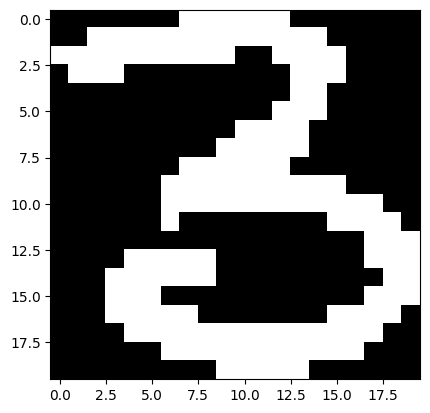

In [7]:
dataset_size = len(train_dataset)
random_index = random.randint(0, dataset_size - 1)

if small_mnist:
    image = train_loader.dataset[random_index][0].reshape(20, 20)
else:
    image = train_loader.dataset[random_index][0].reshape(28, 28)
plt.imshow(image, cmap='gray')

##### DiffLogic Class

In [8]:
class DiffLogic(nn.Module):
    def __init__(self, layers_config, output_size, tau=30):
        """
        Initializes the DiffLogic model with the specified layer configurations, output size, and temperature parameter.

        Args:
            layers_config (dict): Configuration for each logic layer, including dimensions, device, implementation, connections, and grad factor.
            output_size (int): The number of output groups.
            tau (int): Temperature parameter for the GroupSum operation.
        """
        super(DiffLogic, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        for layer_name, config in layers_config.items():
            layer = LogicLayer(
                in_dim=config['in_dim'],
                out_dim=config['out_dim'],
                device=config['device'],
                implementation=config['implementation'],
                connections=config['connections'],
                grad_factor=config['grad_factor']       
            )
            layers.append(layer)
            print(layer)
        
        self.logic_layers = nn.Sequential(*layers)
        
        self.group = GroupSum(k=output_size, tau=tau)
    
    def forward(self, x):
        """
        Forward pass of the DiffLogic model.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after processing through the logic layers and grouping operation.
        """
        # Move tensor to GPU
        if torch.cuda.is_available():
            x = x.to('cuda')          
        x = self.flatten(x)
        logits = self.logic_layers(x)
        group = self.group(logits)
        return group

##### Model Class

In [9]:
class Model(nn.Module):
    def __init__(self, cfg):
        """
        Initializes the Model, loads the DiffLogic model, sets up the optimizer, loss function, and other necessary configurations.

        Args:
            cfg (dict): Configuration dictionary containing model parameters such as layer configurations, output size, tau, and learning rate.
        """
        super(Model, self).__init__()
        
        layers_config = cfg["layers_config"]
        output_size = cfg["output_size"]
        tau = cfg["tau"]
                
        self.diff_logic_model = DiffLogic(layers_config, output_size=output_size, tau=tau)
        self.optimizer = torch.optim.Adam(self.diff_logic_model.parameters(), lr=cfg["learning_rate"])
        self.log_text = ""  # Initialize the logging string
        self.data_batch = []
        self.criterion = nn.CrossEntropyLoss() # loss function for classification tasks

    def forward(self, prediction_dict):    
        """
        Forward pass to predict the model output.

        Args:
            prediction_dict (dict): Dictionary containing input data for making predictions.

        Returns:
            None: Updates the prediction_dict with the predicted output data.
        """
        input_data = prediction_dict["input_data"]
        output = self.diff_logic_model(input_data)
        self.log_text += f"State Prediction: {output}\n"
        prediction_dict["pred_output_data"] = output

    def loss(self, prediction, label):
        """
        Computes the loss between the predicted and true labels.

        Args:
            prediction (torch.Tensor): Predicted tensor output from the model.
            label (torch.Tensor): True labels tensor.

        Returns:
            torch.Tensor: The computed loss value.
        """
        return self.criterion(prediction, label)

    def step(self):
        """
        Updates the model parameters by performing a single optimization step.

        Returns:
            None
        """
        self.optimizer.step()

    def train(self, tdata, mem, batch_size):
        """
        Training method that returns the loss after receiving a batch of data.

        Args:
            tdata (any): Training data.
            mem (any): Memory buffer or additional data needed for training.
            batch_size (int): Size of the data batch for training.

        Returns:
            torch.Tensor: The loss value for the batch.
        """
        self.optimizer.zero_grad()
        loss = torch.tensor([0.0 for i in range(batch_size)])
        return loss

    def test_train(self, prediction_dict):
        """
        Training method for system development on a dummy dataset.

        Args:
            prediction_dict (dict): Dictionary containing predicted and true output data.

        Returns:
            torch.Tensor: The computed loss.
        """
        self.optimizer.zero_grad()
        loss = self.loss(prediction_dict["pred_output_data"], prediction_dict["true_output_data"]).flatten()  # Structure loss (DNN relies on down-stream prediction)  
        return loss

    def save(self, file_path, model_name='model'):
        """
        Saves the model's state dictionary to the specified file path.

        Args:
            file_path (str): Path where the model will be saved.
            model_name (str): Name of the saved model

        Returns:
            None
        """
        torch.save({
            'model_state_dict': self.diff_logic_model.state_dict(),
            'connections': [layer.indices for layer in self.diff_logic_model.logic_layers if isinstance(layer, LogicLayer)]
        }, os.path.join(file_path, f"{model_name}.pth"))
        self.log_text += f"Model saved to: {file_path}\n"

    def load(self, file_path):
        """
        Loads the model's state dictionary from the specified file path.

        Args:
            file_path (str): Path from which the model will be loaded.

        Returns:
            None
        """
        checkpoint = torch.load(file_path)
        self.diff_logic_model.load_state_dict(checkpoint['model_state_dict'])

        # Assign connections to each LogicLayer
        for idx, layer in enumerate(self.diff_logic_model.logic_layers):
            if isinstance(layer, LogicLayer):
                layer.indices = checkpoint['connections'][idx]

        self.diff_logic_model.eval()
        self.log_text += f"Model loaded from: {file_path}\n"

    def plot_loss(self, loss_history):
        """
        Plots the training loss over epochs.

        Args:
            loss_history (list): List containing the loss values for each epoch.

        Returns:
            None
        """
        plt.figure()
        plt.plot(loss_history, label='Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Epochs')
        plt.legend()
        plt.show()
        self.log_text += "Loss plot generated\n"

    def visualize_model(self):
        """
        Generates a visualization of the model using a dummy input.

        Returns:
            None
        """
        dummy_input = torch.randn(1, cfg["input_dim"])  # Adjust this as needed based on your input dimensions
        y = self.diff_logic_model(dummy_input)
        g = make_dot(y, params=dict(self.diff_logic_model.named_parameters()))
        g.view()
        self.log_text += "Model visualization generated\n"

    def get_log(self):
        """
        Retrieves the log text and clears the log after retrieval.

        Returns:
            str: The log text.
        """
        log_copy = self.log_text
        self.log_text = ""  # Clear the log after returning
        return log_copy

    def explain(self):
        """
        Placeholder function for explaining the model's decisions.

        Returns:
            None
        """
        return None
    
    def get_accuracy(self, data_loader):
        """
        Calculates the accuracy of the model against a data loader
        
        Args:
            data_loader: a DataLoader object, e.g. train_loader or test_loader
            
        Returns:
            float: The accuracy
        """
        correct = 0
        total = 0
    
        # Ensure model is in evaluation mode
        self.diff_logic_model.eval()

        with torch.no_grad():  # Disable gradient calculation for inference
            for batch_inputs, batch_outputs in tqdm(data_loader, desc="Running Inference"):
                batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

                # Forward pass to get predictions
                outputs = self.diff_logic_model(batch_inputs)

                # Get the predicted class (index of the maximum logit)
                _, predicted = torch.max(outputs.data, 1)

                # Count correct predictions
                total += batch_outputs.size(0)  # Total number of samples in the batch
                correct += (predicted == batch_outputs).sum().item()  # Count correct predictions

        accuracy = correct / total
        return accuracy

##### EarlyStopper class

In [10]:
class EarlyStopper:
    def __init__(self, patience=10, min_delta=0):
        """
        Initializes the EarlyStopper to stop training if the performance doesn't improve after a certain number of epochs.

        Args:
            patience (int): Number of epochs to wait for an improvement.
            min_delta (float): Minimum change to consider an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def should_stop(self, current_loss):
        """
        Check if training should stop based on the current loss.

        Args:
            current_loss (float): The current loss.

        Returns:
            bool: True if training should stop, False otherwise.
        """
        if self.best_loss is None:
            self.best_loss = current_loss
            return False
        elif current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False
        else:
            self.counter += 1
            print("EarlyStopper Triggered: ", self.counter)
            if self.counter >= self.patience:
                return True
            return False

### Single Model

#### Training

In [13]:
from tqdm import tqdm
losses = []
model_name = 'model_077' # use model_077 for the 400x2500 - 2500x2500

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    # Compose the configuration by specifying the config name
    cfg = compose(config_name="mnist_config")

# Access the configuration for a specific model (e.g., model_001)
model_cfg = cfg.models[model_name]
print(model_cfg)

{'input_dim': 784, 'layers_config': {'LogicLayer001': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 784, 'out_dim': 2500}, 'LogicLayer002': {'connections': 'random', 'device': 'cuda', 'grad_factor': 1, 'implementation': 'cuda', 'in_dim': 2500, 'out_dim': 2500}}, 'learning_rate': 0.01, 'output_size': 10, 'tau': 10}


In [14]:
model = Model(model_cfg).to('cuda')

# Initialize EarlyStopper with a patience of  5 epochs
early_stopper = EarlyStopper(patience=5)

num_epochs = 100
losses = []

for epoch in range(num_epochs):
    loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
    epoch_loss = 0  # Track loss for the entire epoch
    
    for batch_inputs, batch_outputs in loop:
        # Move to GPU if available
        batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').long()
        
        # Create prediction dictionary
        prediction_dict = {
            "input_data": batch_inputs, 
            "true_output_data": batch_outputs
        }
                
        # Forward pass
        model.forward(prediction_dict)
        
        # Compute the loss
        loss = model.test_train(prediction_dict)
        
        # Zero gradients, backpropagate, and update the model parameters
        model.optimizer.zero_grad()
        loss.backward()
        model.step()

        # Accumulate the batch loss
        epoch_loss += loss.item()
    
    # Calculate the average loss for the epoch
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1} Loss: {epoch_loss}')

    # Check if we should stop early
    if early_stopper.should_stop(epoch_loss):
        print(f"Early stopping triggered at epoch {epoch+1}. Training stopped.")
        break

KeyboardInterrupt: 

In [116]:
# Save the model after training completes
FILE_PATH = 'trained_binary_models'        
FILE_NAME = f'{model_name}_weights_28x28'
model.save(FILE_PATH, FILE_NAME)   

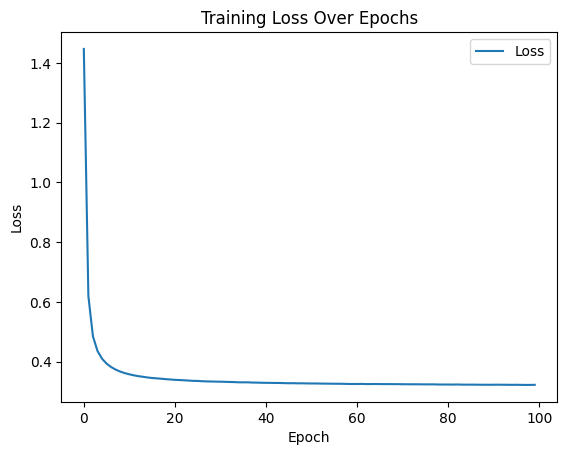

Running Inference: 100%|██████████| 34/34 [00:02<00:00, 13.87it/s]


0.9239430147058824

In [117]:
model.plot_loss(losses)
model.get_accuracy(test_loader)

#### Inference

In [13]:
model_name = 'model_077'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'binarized_{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models/trained_binary_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
# print(model)

model.get_accuracy(test_loader)

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)


Running Inference: 100%|██████████| 34/34 [00:08<00:00,  3.79it/s]


0.9237132352941176

#### Switching Probability

In [52]:
import numpy as np
from PIL import Image

def load_averaged_mnist_image(path):
    """
    Loads the averaged MNIST image and converts it to a normalized probability map (0 to 1).
    Trims the image from 28x28 to 20x20 by removing 4 pixels from each side.
    """
    # Load the image and convert to grayscale ('L' mode)
    image = Image.open(path).convert('L')
    
    # Convert to numpy array for trimming and normalization
    img = np.array(image)
    
    # Trim the image: remove 4 pixels from each side to get a 20x20 image
    trim_top = 4
    trim_bottom = 4
    trim_left = 4
    trim_right = 4
    img = img[trim_top:28 - trim_bottom, trim_left:28 - trim_right]
    
    # Normalize the pixel values to the range [0, 1]
    img = img / 255.0
    
    return img

avg_digits_prob_map = load_averaged_mnist_image('mnist_averaged_digits/average_all_digits.png')

# To check the shape of the resulting image (should be 20x20)
print(avg_digits_prob_map.shape)

(20, 20)


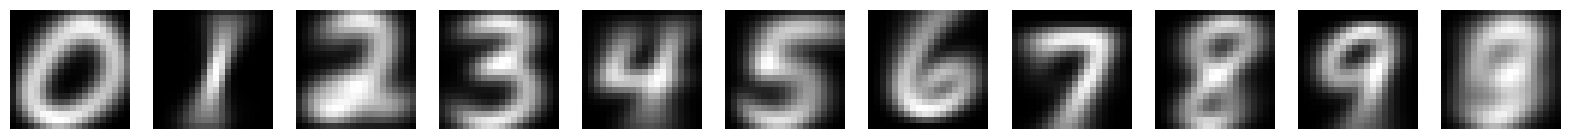

In [53]:
# Load the averaged MNIST image for each digit and all digits
all_digits_prob_map = []

for i in range(10):
    temp_map = load_averaged_mnist_image(f'mnist_averaged_digits/average_digit_{i}.png')
    all_digits_prob_map.append(temp_map)
all_digits_prob_map.append(avg_digits_prob_map)


fig, axes = plt.subplots(1, 11, figsize=(20, 2))  # 1 row, 11 columns

for i, ax in enumerate(axes):
    ax.imshow(all_digits_prob_map[i], cmap='gray')  
    ax.axis('off') 

note, the 7 looks less centered than other digits, this could affect our learned logic gates.

In [54]:
## the highest probability for each of the digits above, which makes sense.
for i in all_digits_prob_map:
    print(np.max(i))

0.788235294117647
0.9647058823529412
0.6901960784313725
0.7764705882352941
0.8392156862745098
0.6823529411764706
0.8352941176470589
0.7647058823529411
0.8313725490196079
0.8196078431372549
0.5450980392156862


In [55]:
def get_pixel_probability(mnist_prob_map, neuron_idx):
    """
    Fetches the pixel probability corresponding to the neuron's input.
    
    Args:
        mnist_prob_map: The 20x20 averaged MNIST image with pixel probabilities.
        neuron_idx: The index of the input neuron corresponding to the pixel.
    
    Returns:
        Probability value (float) for the corresponding input neuron.
    """
    # Map the neuron index to a 20x20 grid
    row, col = divmod(neuron_idx, 20)
    
    # Check if the row and col are within bounds
    if row >= mnist_prob_map.shape[0] or col >= mnist_prob_map.shape[1]:
        print(f"Warning: Neuron index {neuron_idx} is out of bounds for the MNIST map.")
        return 0  # Return a default value, or handle it as needed
    
    return mnist_prob_map[row, col]

# [4] corresponds to the digit 4
# 211 is an arbitrary choice to get a value in the middle of the image
get_pixel_probability(all_digits_prob_map[4], 211) # 10 (y value) * 20 pixels + 11 (x value)

0.6078431372549019

In [57]:
# ALL_OPERATIONS is used to map the argmax value of the weights to the corresponding logic gate
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

# Logic probability for each gate under the assumption that the input is uniform
# e.g. the AND gate can receive 4 different combinations, 01, 10, 11, 00, but only 11 returns true. 
# the logic probability of the AND gate is therefore 1/4 or 0.25 because only 11 returns true.
ALL_OPERATIONS_PROBS = {
    "zero": 0.00, "and": 0.25, "not_implies": 0.25, "a": 0.50, "not_implied_by": 0.25,
    "b": 0.50, "xor": 0.50, "or": 0.75, "not_or": 0.25, "not_xor": 0.50,
    "not_b": 0.50, "implied_by": 0.75, "not_a": 0.50, "implies": 0.75,
    "not_and": 0.75, "one": 1.00
}

In [58]:
# a and b are inputs to the logic gate, which returns z
# a - \
#      -- logic_gate --> z
# b - /
# e.g. a=1(True) b=0(False) logic_gate='AND', z=0(False)

In [59]:
def calculate_prob_z(learned_gate, prob_a, prob_b):
    """
    Calculate the probability Z based on the learned gate and input probabilities prob_a and prob_b.
    
    Args:
    learned_gate (str): The logic gate to apply (from ALL_OPERATIONS).
    prob_a (float): The probability of input A.
    prob_b (float): The probability of input B.
    
    Returns:
    prob_z (float): The resulting probability based on the gate logic.
    """
    
    if learned_gate == 'zero':  # False
        return 0
    elif learned_gate == 'and':  # A ∧ B
        return prob_a * prob_b
    elif learned_gate == 'not_implies':  # ¬(A ⇒ B) = A - A*B
        return prob_a - prob_a * prob_b
    elif learned_gate == 'a':  # A
        return prob_a
    elif learned_gate == 'not_implied_by':  # ¬(A ⇐ B) = B - A*B
        return prob_b - prob_a * prob_b
    elif learned_gate == 'b':  # B
        return prob_b
    elif learned_gate == 'xor':  # A ⊕ B = A + B - 2*A*B
        return prob_a + prob_b - 2 * prob_a * prob_b
    elif learned_gate == 'or':  # A ∨ B = A + B - A*B
        return prob_a + prob_b - prob_a * prob_b
    elif learned_gate == 'not_or':  # ¬(A ∨ B) = 1 - (A + B - A*B)
        return 1 - (prob_a + prob_b - prob_a * prob_b)
    elif learned_gate == 'not_xor':  # ¬(A ⊕ B) = 1 - (A + B - 2*A*B)
        return 1 - (prob_a + prob_b - 2 * prob_a * prob_b)
    elif learned_gate == 'not_b':  # ¬B = 1 - B
        return 1 - prob_b
    elif learned_gate == 'implied_by':  # A ⇐ B = 1 - B + A*B
        return 1 - prob_b + prob_a * prob_b
    elif learned_gate == 'not_a':  # ¬A = 1 - A
        return 1 - prob_a
    elif learned_gate == 'implies':  # A ⇒ B = 1 - A + A*B
        return 1 - prob_a + prob_a * prob_b
    elif learned_gate == 'not_and':  # ¬(A ∧ B) = 1 - A*B
        return 1 - prob_a * prob_b
    elif learned_gate == 'one':  # True
        return 1

In [60]:
# Lists to store activation counts and gates per layer
activation_counts_per_layer = []  # To store the number of times neurons in each layer fire
gates_per_layer = []              # To store the learned gates and associated inputs for each neuron in each layer
hooks = []                        # Placeholder for storing hook handles (for possible removal later if needed)

# Function to record gates for a layer and compute gate probabilities for each probability map
def record_gates_for_prob_maps(module, layer_idx, prob_maps, debug=False):
    """
    Records the learned gates and computes gate probabilities for each probability map.

    Args:
    module (nn.Module): The layer whose gates are being recorded.
    layer_idx (int): The index of the layer in the network.
    prob_maps (list of Tensors): List of MNIST images where each pixel's intensity corresponds to a probability.
    debug (boolean): Whether you want to print information to the screen.
    """
    # Initialize gates_per_layer for this layer
    if len(gates_per_layer) <= layer_idx:
        gates_per_layer.append([])

    num_prob_maps = len(prob_maps)

    # For each neuron in the layer
    for neuron_idx in range(module.weights.size(0)):
        # Get the learned gate by taking the argmax of the weights for the neuron
        gate_op_idx = module.weights[neuron_idx].argmax().item()
        learned_gate = ALL_OPERATIONS[gate_op_idx]

        # Get the input connections (indices) for the gate
        input_neuron_a = module.indices[0][neuron_idx].item()
        input_neuron_b = module.indices[1][neuron_idx].item()

        if debug:
            print(f'Layer {layer_idx}, Neuron {neuron_idx}')
            print('IN A', input_neuron_a)
            print('IN B', input_neuron_b)

        # Compute probabilities for each probability map
        prob_list = []
        for prob_map_idx, mnist_prob_map in enumerate(prob_maps):
            # Fetch pixel probabilities from the MNIST map
            prob_a = get_pixel_probability(mnist_prob_map, input_neuron_a)
            prob_b = get_pixel_probability(mnist_prob_map, input_neuron_b)

            # Calculate prob_z based on the learned gate
            prob_z = calculate_prob_z(learned_gate, prob_a, prob_b)

            prob_list.append({
                'prob_a': prob_a,
                'prob_b': prob_b,
                'prob_z': prob_z,
            })

        # Store gate information and probabilities per probability map
        gates_per_layer[layer_idx].append({
            'Gate': learned_gate,
            'Inputs': (input_neuron_a, input_neuron_b),
            'a': input_neuron_a,
            'b': input_neuron_b,
            'probabilities': prob_list,  # List of probabilities for each probability map
        })

# Hook function to track activations for each neuron
def hook_fn(module, input, output, layer_idx, debug=False):
    """
    This function gets attached as a hook to a layer of a neural network.
    It tracks the activations of neurons for the specific layer.

    Args:
    module (nn.Module): The layer being tracked.
    input (Tensor): The input to the layer (not used in this function).
    output (Tensor): The output from the layer (activations of the neurons).
    layer_idx (int): The index of the layer in the network.
    debug (boolean): Whether you want to print information to the screen.
    """
    if debug:
        print('module:', module)
        print('input:', input)
        print('output', output)
        print('Output shape:', output.shape)
        print('layer_idx', layer_idx)
        print('input size', len(input))
        print('output size', len(output))

    # Initialize activation counts for the layer if not done already
    if len(activation_counts_per_layer) <= layer_idx:
        activation_counts_per_layer.append(np.zeros(output.size(1)))

    # Store activations (output > 0 means it fired)
    activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

In [61]:
data_loader = train_loader

In [62]:
# all_digits_prob_map is a list of probability maps
# For example, all_digits_prob_map[0] corresponds to digit 0, etc.
# and the last element is the averaged MNIST probability map
prob_maps = all_digits_prob_map 

# Record gates and compute probabilities for each probability map
for idx, layer in enumerate(model.diff_logic_model.logic_layers):
    """
    Loops through all layers in the model's `diff_logic_model.logic_layers` and records gates
    for each layer that is an instance of `LogicLayer`.
    """
    # WE ARE ONLY INTERESTED IN THE FIRST LAYER FOR THIS EXPERIMENT
    if idx == 0: # or idx == 1 !!! this requires code fixes to work
        if isinstance(layer, LogicLayer):
            # Record gates for this layer and compute probabilities for each probability map
            record_gates_for_prob_maps(layer, idx, prob_maps)

            # Register a forward hook on the layer to accumulate activation counts
            hook = layer.register_forward_hook(
                lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx)
            )

            # Append the hook handle to the hooks list for possible removal later
            hooks.append(hook)

# Set model to eval mode and track total number of images processed
model.diff_logic_model.eval()
total_images = 0

# Disable gradient computation and run forward pass
with torch.no_grad():
    for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
        batch_inputs = batch_inputs.to('cuda')
        model.diff_logic_model(batch_inputs)
        total_images += batch_inputs.size(0)

Processing MNIST images: 100%|██████████| 211/211 [00:10<00:00, 19.50it/s]


In [63]:
layer_probs = []

# Empty list of dictionaries for each probability map
gate_prob_dicts = [{} for _ in range(len(prob_maps))]  

# Calculate switching frequencies and Switching Gate (SG) for the first layer
layer_probs = activation_counts_per_layer[0] / total_images  # This is the actual switching frequency (SF) for the layer
layer_probs

array([1.49392773, 0.8142032 , 0.37659212, ..., 0.63484893, 0.43020586,
       1.92579976])

In [65]:
def calculate_switching_gain(switching_prob, logic_prob):
    """
    Safely calculates the Switching Gain (SG) = SP / LP.
    """
    if logic_prob == 0:
        return 0  
    else:
        return switching_prob / logic_prob

In [66]:
for i, gate_info in enumerate(gates_per_layer[0]):
    learned_gate = gate_info['Gate']
    actual_prob = layer_probs[i]  # This is the switching frequency (SF)
    predicted_prob = ALL_OPERATIONS_PROBS[learned_gate]  # This is the logic probability (LP) assuming inputs are random

    # For each probability map, calculate the Switching Gate (SG)
    for prob_map_idx, probs in enumerate(gate_info['probabilities']):
        prob_a = probs['prob_a']
        prob_b = probs['prob_b']
        prob_z = probs['prob_z']  # This is the switching probability (SP)

        # Calculate the Switching Gate (SG = SP / LP)
        switching_gain = calculate_switching_gain(prob_z, predicted_prob)

        # Store gate information and probabilities
        gate_prob_dicts[prob_map_idx][f"Gate {i+1}"] = {
            "Learned Gate": learned_gate,
            "Inputs": gate_info['Inputs'],
            "Switching Frequency": actual_prob,  # SF (same for all probability maps)
            "Logic Probability": predicted_prob,  # LP (same for all probability maps)
            "a": gate_info['a'],
            "prob_a": prob_a,
            "b": gate_info['b'],
            "prob_b": prob_b,
            "Switching Probability (prob_z)": prob_z,  # SP
            "Switching Gain (SP/LP)": switching_gain  # SG
        }

# Remove hooks after calculation
for hook in hooks:
    hook.remove()

    
# Function to calculate the average SG for each pixel for each probability map
def calculate_sg_for_pixels_per_prob_map(gate_prob_dicts, image_size=400):
    # List to store sg_per_pixel for each probability map
    sg_per_pixel_list = []

    for gate_dict in gate_prob_dicts:
        # Array to store the final average SG for each pixel (length 400)
        sg_per_pixel = [0] * image_size

        # Traverse through the image inputs
        for i in range(image_size):  # i represents a pixel index (0 to 399)
            sg_sum = 0  # Accumulate SG for this pixel
            gate_count = 0  # Count how many gates this pixel contributes to

            # Traverse through all the gates in the dictionary
            for gate_key in gate_dict:
                gate = gate_dict[gate_key]  # Get the gate data

                input_A, input_B = gate['Inputs']  # Unpack the gate's input A and B

                # Check if pixel i is either input_A or input_B for the current gate
                if i == input_A or i == input_B:
                    sg = gate['Switching Gain (SP/LP)']  # Get the Switching Gate (SG) for the gate
                    sg_sum += sg  # Add this SG to the sum for pixel i
                    gate_count += 1  # Increment the number of gates this pixel contributes to

            # Calculate the average SG for pixel i
            if gate_count > 0:
                sg_per_pixel[i] = sg_sum / gate_count  # Average SG for pixel i
            else:
                sg_per_pixel[i] = 0  # If the pixel doesn't contribute to any gate, set SG to 0

        sg_per_pixel_list.append(sg_per_pixel)

    return sg_per_pixel_list


# Example call to the function
sg_per_pixel_list = calculate_sg_for_pixels_per_prob_map(gate_prob_dicts)

# Now, sg_per_pixel_list is a list where each element corresponds to the sg_per_pixel for a probability map
# You can access sg_per_pixel for the ith probability map using sg_per_pixel_list[i]

In [86]:
def aggregate_pixel_values(gates, num_pixels=400):
    """
    Aggregates and averages values for each pixel across all gates.
    
    Args:
        gates (list of dict): List of gates with associated metrics.
        num_pixels (int): Total number of pixels. Defaults to 400.
    
    Returns:
        dict: A dictionary with each pixel as a key and its averaged metrics.
    """
    # Initialize dictionaries to accumulate values for each metric
    pixel_data = {
        'logic_probability': [0.0] * num_pixels,
        'switching_probability': [0.0] * num_pixels,
        'switching_gain': [0.0] * num_pixels,
        'switching_frequency': [0.0] * num_pixels,
        'overall_probability': [0.0] * num_pixels,
        'counts': [0] * num_pixels  # To keep track of the count per pixel for averaging
    }
    
    # Iterate over each gate and accumulate values for pixels a and b
    for gate in gates:
        for pixel in ('a', 'b'):
            print(pixel)
            idx = gate[pixel]
            
            # Accumulate values
            pixel_data['logic_probability'][idx] += gate['Logic Probability']
            pixel_data['switching_probability'][idx] += gate['Switching Probability (prob_z)']
            pixel_data['switching_gain'][idx] += gate['Switching Gain (SP/LP)']
            pixel_data['switching_frequency'][idx] += gate['Switching Frequency']
            pixel_data['overall_probability'][idx] += gate[f'prob_{pixel}']
            pixel_data['counts'][idx] += 1
    
    # Average the accumulated values for each pixel
    averaged_data = {}
    for metric in pixel_data:
        if metric == 'counts':
            continue
        averaged_data[metric] = [
            pixel_data[metric][i] / pixel_data['counts'][i] if pixel_data['counts'][i] > 0 else 0
            for i in range(num_pixels)
        ]
    
    return averaged_data

In [88]:
def calculate_metrics_for_pixels_per_prob_map(gate_prob_dicts, image_size=400):
    """
    Calculates the average logic probability, switching probability, switching gain, switching frequency,
    and overall probability for each pixel across multiple gate dictionaries.
    
    Args:
        gate_prob_dicts (list of dict): List of dictionaries, each containing gate metrics.
        image_size (int): Total number of pixels. Defaults to 400 for a 20x20 image.
    
    Returns:
        dict: A dictionary of lists where each list corresponds to the averaged metrics per pixel.
    """
    # Initialize the list of dictionaries to store metrics per pixel for each probability map
    metrics_list_per_prob_map = []

    # Iterate over each gate dictionary (for each digit/probability map)
    for gate_dict in gate_prob_dicts:
        # Initialize arrays to accumulate metrics for each pixel
        logic_prob = [0] * image_size
        switching_prob = [0] * image_size
        switching_gain = [0] * image_size
        switching_freq = [0] * image_size
        overall_prob = [0] * image_size
        pixel_counts = [0] * image_size

        # Iterate over all gates within the current gate dictionary
        for gate_key, gate in gate_dict.items():
            input_A, input_B = gate['Inputs']

            # Function to accumulate metrics for a given pixel
            def accumulate_metrics(pixel_idx):
                logic_prob[pixel_idx] += gate.get('Logic Probability', 0)
                switching_prob[pixel_idx] += gate.get('Switching Probability (prob_z)', 0)
                switching_gain[pixel_idx] += gate.get('Switching Gain (SP/LP)', 0)
                switching_freq[pixel_idx] += gate.get('Switching Frequency', 0)
                overall_prob[pixel_idx] += gate.get(f'prob_a', 0) if pixel_idx == input_A else gate.get(f'prob_b', 0)
                pixel_counts[pixel_idx] += 1

            # Accumulate metrics for both input A and B
            accumulate_metrics(input_A)
            accumulate_metrics(input_B)

        # Calculate the average for each metric per pixel
        metrics = {
            'logic_probability': [logic_prob[i] / pixel_counts[i] if pixel_counts[i] > 0 else 0 for i in range(image_size)],
            'switching_probability': [switching_prob[i] / pixel_counts[i] if pixel_counts[i] > 0 else 0 for i in range(image_size)],
            'switching_gain': [switching_gain[i] / pixel_counts[i] if pixel_counts[i] > 0 else 0 for i in range(image_size)],
            'switching_frequency': [switching_freq[i] / pixel_counts[i] if pixel_counts[i] > 0 else 0 for i in range(image_size)],
            'overall_probability': [overall_prob[i] / pixel_counts[i] if pixel_counts[i] > 0 else 0 for i in range(image_size)]
        }

        # Append the metrics dictionary for this probability map to the list
        metrics_list_per_prob_map.append(metrics)

    return metrics_list_per_prob_map

# Example usage:
metrics_list_per_prob_map = calculate_metrics_for_pixels_per_prob_map(gate_prob_dicts)

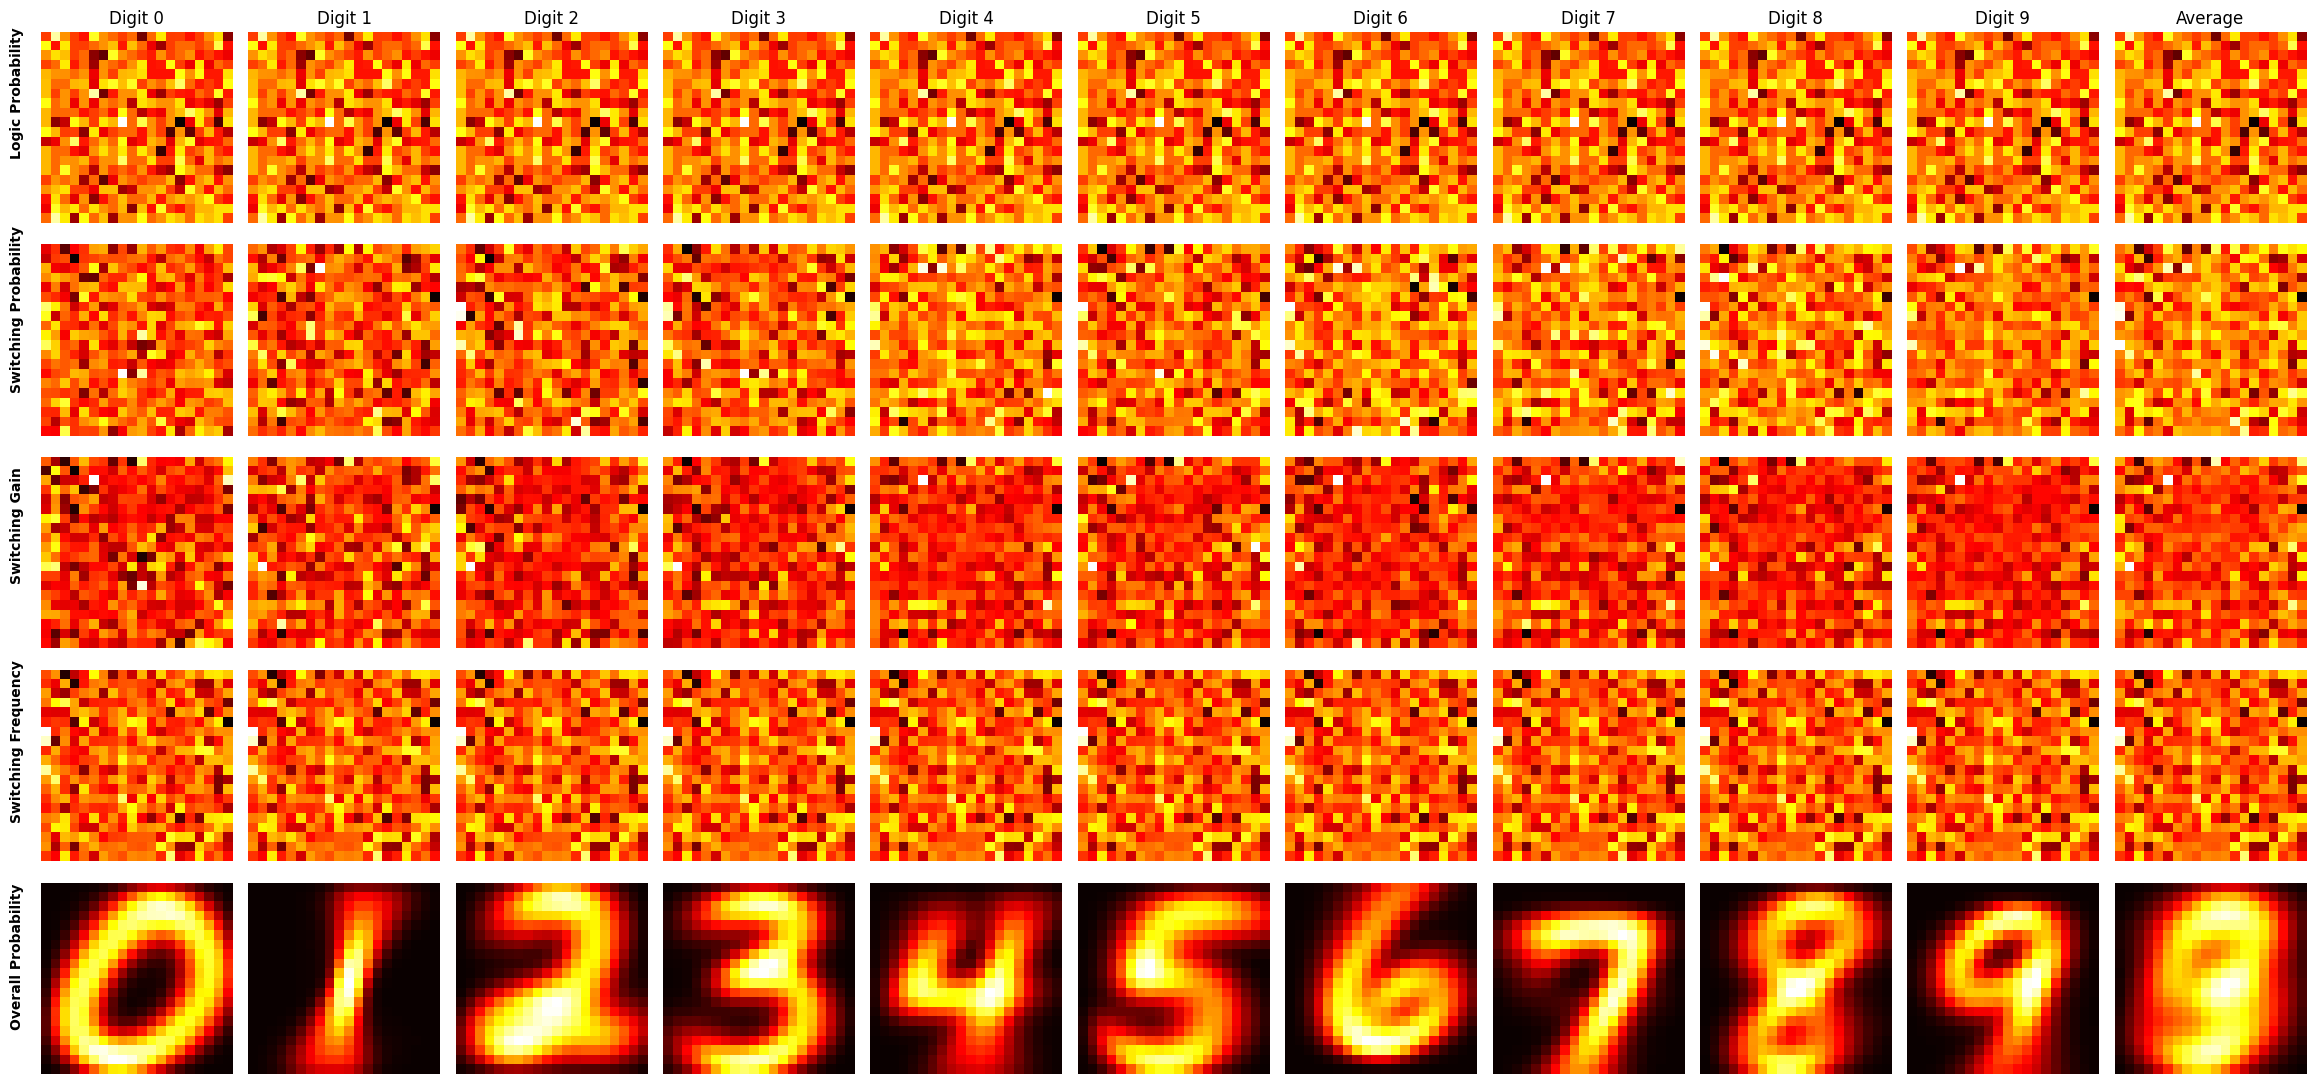

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Define column and row labels
digit_labels = [f'Digit {i}' for i in range(10)] + ['Average']
metric_labels = ['Logic Probability', 'Switching Probability', 'Switching Gain', 'Switching Frequency', 'Overall Probability']

# Create the subplot grid
fig, axes = plt.subplots(nrows=5, ncols=11, figsize=(24, 12))

# Set the column titles (digits and average) on the top row
for ax, col_label in zip(axes[0], digit_labels):
    ax.set_title(col_label, fontsize=12)

# Add metric labels on the left side using fig.text to position them outside the main plotting area
for i, row_label in enumerate(metric_labels):
    fig.text(0.04, 0.84 - i * 0.18, row_label, ha='center', va='center', rotation=90, fontsize=10, fontweight='bold')

# Plot each metric for each digit/average
for row, metric in enumerate(metric_labels):
    for col in range(11):
        data = np.reshape(metrics_list_per_prob_map[col][metric.replace(' ', '_').lower()], (20, 20))
        im = axes[row, col].imshow(data, cmap='hot')
        axes[row, col].axis('off')  # Hide axes for a cleaner look

# Add a color bar to the right of the grid
# fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.tight_layout(rect=[0.1, 0, 1, 1])  # Adjust to fit text on the left
plt.subplots_adjust(left=0.05, top=0.9)  # Adjust left padding for labels

plt.show()


In [67]:
max(sg_per_pixel_list[0]), min(sg_per_pixel_list[0])

(1.755278738946559, 0.5372639714508227)

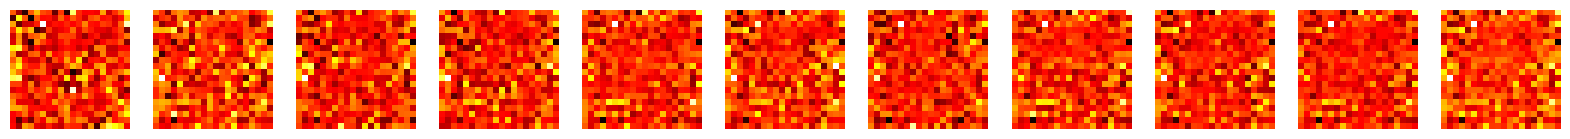

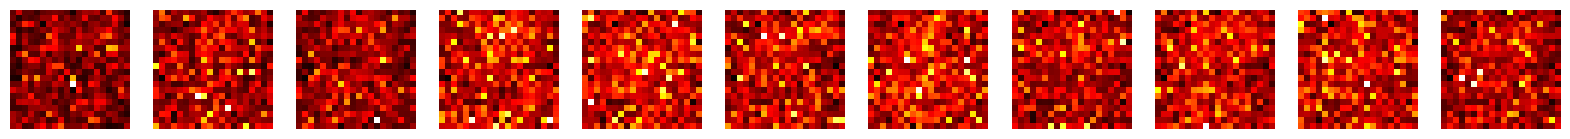

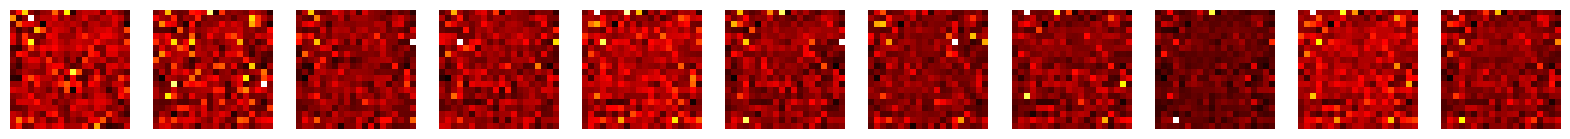

In [76]:
normalized_sg_per_pixel_list = []
for i in range(11):
    temp_avg = sg_per_pixel_list[i] / max(sg_per_pixel_list[i])
    normalized_sg_per_pixel_list.append(temp_avg)

fig, axes = plt.subplots(1, 11, figsize=(20, 2))  # 1 row, 11 columns

for i, ax in enumerate(axes):
    ax.imshow(np.reshape(sg_per_pixel_list[i], (20, 20)), cmap='hot')  
    ax.axis('off') 
    
# Convert sg_per_pixel_list (list of lists) to a 2D NumPy array
normalized_sg_per_pixel_list = np.array(normalized_sg_per_pixel_list)  # Shape: (num_prob_maps, num_pixels)

# Compute the logged SG per pixel for all probability maps
logged_sg_per_pixel_array = np.log(1 / (np.abs(0.5 - normalized_sg_per_pixel_list) + 1e-10))

# Convert back to list of lists if needed
logged_sg_per_pixel_list = logged_sg_per_pixel_array.tolist()

fig, axes = plt.subplots(1, 11, figsize=(20, 2))  # 1 row, 11 columns
for i, ax in enumerate(axes):
    ax.imshow(np.reshape(logged_sg_per_pixel_list[i], (20, 20)), cmap='hot')  
    ax.axis('off') 
    
# Convert sg_per_pixel_list (list of lists) to a 2D NumPy array
sg_per_pixel_array = np.array(sg_per_pixel_list)  # Shape: (num_prob_maps, num_pixels)

# Compute the logged SG per pixel for all probability maps
logged_sg_per_pixel_array = np.log(1 / (np.abs(0.5 - sg_per_pixel_array) + 1e-10))

# Convert back to list of lists if needed
logged_sg_per_pixel_list = logged_sg_per_pixel_array.tolist()

fig, axes = plt.subplots(1, 11, figsize=(20, 2))  # 1 row, 11 columns
for i, ax in enumerate(axes):
    ax.imshow(np.reshape(logged_sg_per_pixel_list[i], (20, 20)), cmap='hot')  
    ax.axis('off') 

In [70]:
def get_top_5_gates_by_prob_z(gate_dict):
    # Create a list of tuples where each tuple contains ('Gate Name', 'Switching Probability (prob_z)')
    gate_prob_list = [(gate_name, gate_data['Switching Probability (prob_z)'])
                      for gate_name, gate_data in gate_dict.items()]
    
    # Sort the list by 'Switching Probability (prob_z)' in descending order
    sorted_gates = sorted(gate_prob_list, key=lambda x: x[1], reverse=True)
    
    # Get the top 5 gates
    top_5_gates = sorted_gates[:5]
    
    return top_5_gates

# Example usage
top_5_gates = get_top_5_gates_by_prob_z(gate_prob_dicts)

AttributeError: 'list' object has no attribute 'items'

In [167]:
# List of probability map names (adjust as per your actual maps)
prob_map_names = ['Digit 0', 'Digit 1', 'Digit 2', 'Digit 3', 'Digit 4',
                  'Digit 5', 'Digit 6', 'Digit 7', 'Digit 8', 'Digit 9', 'Average']

# Initialize a dictionary to hold the data
gate_data = {}

# Iterate over each probability map
for prob_map_idx, gate_prob_dict in enumerate(gate_prob_dicts):
    prob_map_name = prob_map_names[prob_map_idx]
    
    # Iterate over each gate in the probability map
    for gate_name, gate_info in gate_prob_dict.items():
        prob_z = gate_info['Switching Probability (prob_z)']
        
        # Initialize the gate entry if not already present
        if gate_name not in gate_data:
            gate_data[gate_name] = {}
        
        # Store the prob_z for this gate and probability map
        gate_data[gate_name][prob_map_name] = prob_z

In [187]:
# Create a DataFrame from the gate data
df = pd.DataFrame.from_dict(gate_data, orient='index')

# Ensure that the columns are in the correct order
df = df[prob_map_names]

for i in range(10): 
    print(sum(df[f'Digit {i}'])/2500)

0.49463406997308923
0.4948704590542089
0.49283481122645206
0.4984198446751243
0.5010823098808158
0.4990513371780072
0.4941599876970397
0.5022168335255663
0.49466878892733557
0.5023638415993853


In [182]:
df.loc['Gate 1001']

Digit 0    1.0
Digit 1    1.0
Digit 2    1.0
Digit 3    1.0
Digit 4    1.0
Digit 5    1.0
Digit 6    1.0
Digit 7    1.0
Digit 8    1.0
Digit 9    1.0
Average    1.0
Name: Gate 1001, dtype: float64

In [170]:
# Calculate the average prob_z across all probability maps
df['Average_prob_z'] = df.mean(axis=1)

# Sort the DataFrame by the average prob_z in descending order
df_sorted = df.sort_values(by='Average_prob_z', ascending=False)

# Select the top 5 gates
top_n = 5
top_gates = df_sorted.head(top_n)

In [171]:
top_gates

,Digit 0,Digit 1,Digit 2,Digit 3,Digit 4,Digit 5,Digit 6,Digit 7,Digit 8,Digit 9,Average,Average_prob_z
Gate 619,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gate 1129,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gate 1001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gate 763,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gate 1555,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


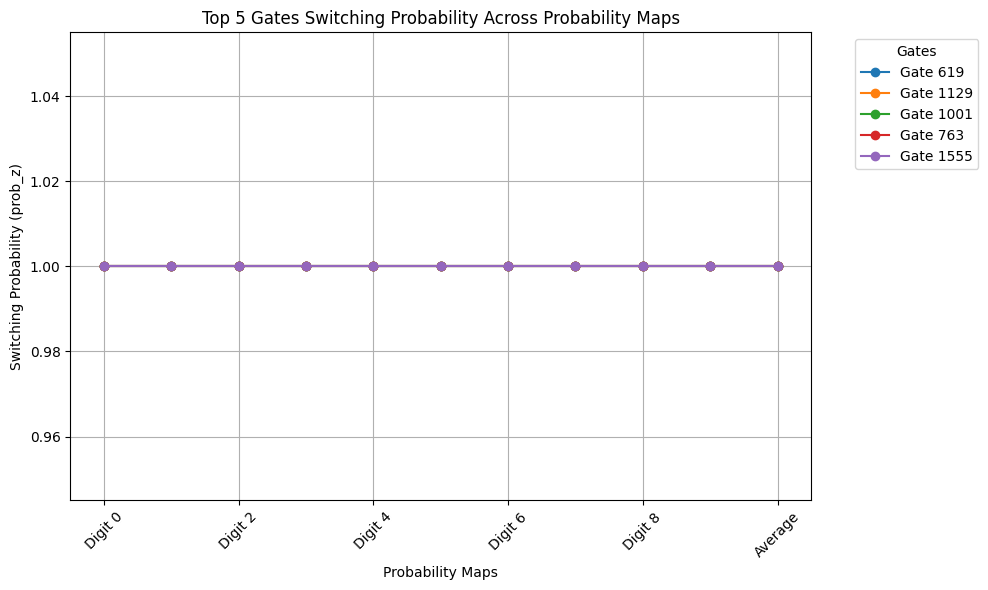

In [172]:
import matplotlib.pyplot as plt

# Exclude the 'Average_prob_z' column for plotting
plot_data = top_gates.drop(columns=['Average_prob_z'])

# Transpose the DataFrame for plotting (probability maps on the x-axis)
plot_data = plot_data.T

# Plot the data
plot_data.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Top 5 Gates Switching Probability Across Probability Maps')
plt.xlabel('Probability Maps')
plt.ylabel('Switching Probability (prob_z)')
plt.legend(title='Gates', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**Calculating Average Switching Gate**

In [48]:
# Function to calculate the average SG for each pixel
def calculate_sg_for_pixels(gate_dict, image_size=400, dict_size=2500):
    # Array to store the final average SG for each pixel (length 400)
    sg_per_pixel = [0] * image_size

    # Traverse through the image inputs 
    for i in range(image_size):  # i represents a pixel index (0 to 399)
        sg_sum = 0  # Accumulate SG for this pixel
        gate_count = 0  # Count how many gates this pixel contributes to
        
        # Traverse through all the gates in the dictionary
        for j in range(dict_size):  # j corresponds to gates
            gate = gate_dict.get(f'Gate {j+1}')  # Get the gate data for gate j
                  
            if gate:
                input_A, input_B = gate['Inputs']  # Unpack the gate's input A and B
                
                # Check if pixel i is either input_A or input_B for the current gate
                if i == input_A or i == input_B:
                    
                    sg = gate['Switching Gate (SP/LP)']  # Get the Switching Gate (SG) for the gate
                    sg_sum += sg  # Add this SG to the sum for pixel i
                    gate_count += 1  # Increment the number of gates this pixel contributes to
                
                    if i == 0 and False: # for debug only
                        print(i, input_A, input_B, gate)
                    
        
        # Calculate the average SG for pixel i
        if gate_count > 0:
            # print(gate_count) -- all pixels seem to uniformly contribute to 12/13 gates
            sg_per_pixel[i] = sg_sum / gate_count  # Average SG for pixel i
        else:
            sg_per_pixel[i] = 0  # If the pixel doesn't contribute to any gate, set SG to 0
    
    return sg_per_pixel

# Example call to the function
sg_per_pixel = calculate_sg_for_pixels(gate_prob_dict)

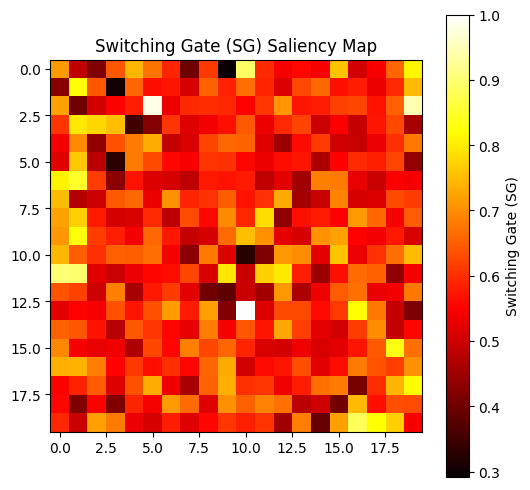

In [50]:
image_size = 20 
sg_map = np.array(sg_per_pixel).reshape((image_size, image_size))
sg_map = sg_map / sg_map.max()

plt.figure(figsize=(6, 6))  
plt.imshow(sg_map, cmap='hot', interpolation='nearest') 
plt.colorbar(label='Switching Gate (SG)') 
plt.title('Switching Gate (SG) Saliency Map')
plt.show()

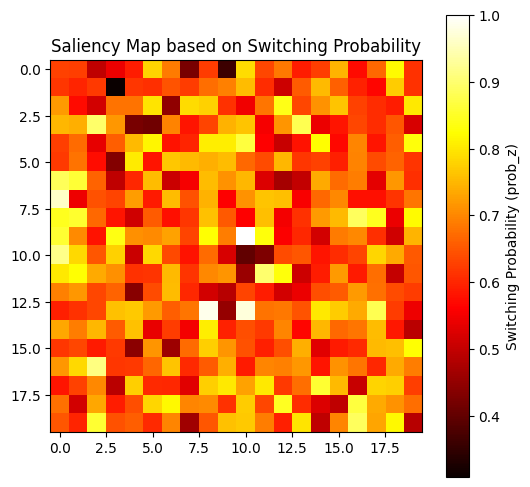

In [65]:
# Initialize a 20x20 grid for the MNIST-like data (use zeros for saliency initialization)
grid_size = 20
saliency_map = np.zeros((grid_size, grid_size))

# Helper function to convert neuron index to (row, col) position on 20x20 grid
def neuron_to_grid(neuron_idx, grid_size=20):
    row, col = divmod(neuron_idx, grid_size)
    return row, col

# Update the saliency map with the True Switching Probabilities from gate data
for gate, info in gate_prob_dict.items():
    # Get the input neurons and the true switching probability
    neuron_a, neuron_b = info['Inputs']
    prob_z = info['Switching Probability (prob_z)']
    
    # Map the neurons to their corresponding grid positions
    row_a, col_a = neuron_to_grid(neuron_a, grid_size)
    row_b, col_b = neuron_to_grid(neuron_b, grid_size)
    
    # Update the grid positions with the true switching probability (accumulate the values)
    saliency_map[row_a, col_a] += prob_z
    saliency_map[row_b, col_b] += prob_z

# Normalize the saliency map for better visualization (optional, depending on scale)
normalized_saliency_map = saliency_map / saliency_map.max()

# Plotting the saliency map
plt.figure(figsize=(6, 6))
plt.imshow(normalized_saliency_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Switching Probability (prob_z)')
plt.title('Saliency Map based on Switching Probability')
plt.show()

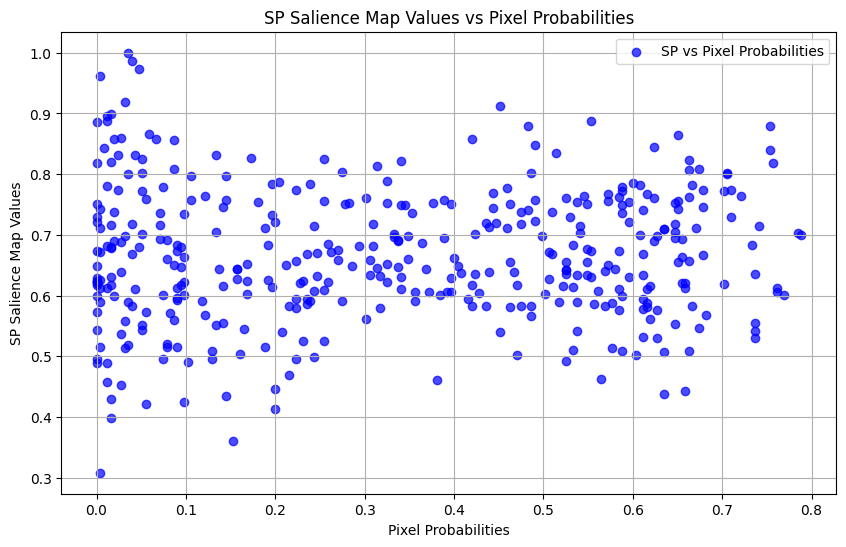

In [75]:
# (1) we should plot the SP salience map values against the pixel probability values. This should be near linear.

def plot_sp_vs_prob(sp_per_pixel, pixel_probabilities):
    plt.figure(figsize=(10, 6))
    
    # Plot SP salience map values against pixel probabilities
    plt.scatter(pixel_probabilities, sp_per_pixel, color='blue', label='SP vs Pixel Probabilities', alpha=0.7)
    
    # Adding a line of best fit (linear regression)
    #plt.plot(pixel_probabilities, sg_per_pixel, color='red', label='Line of Best Fit')
    
    plt.title('SP Salience Map Values vs Pixel Probabilities')
    plt.xlabel('Pixel Probabilities')
    plt.ylabel('SP Salience Map Values')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sp_vs_prob(np.array(normalized_saliency_map).reshape(20,20), mnist_prob_map)

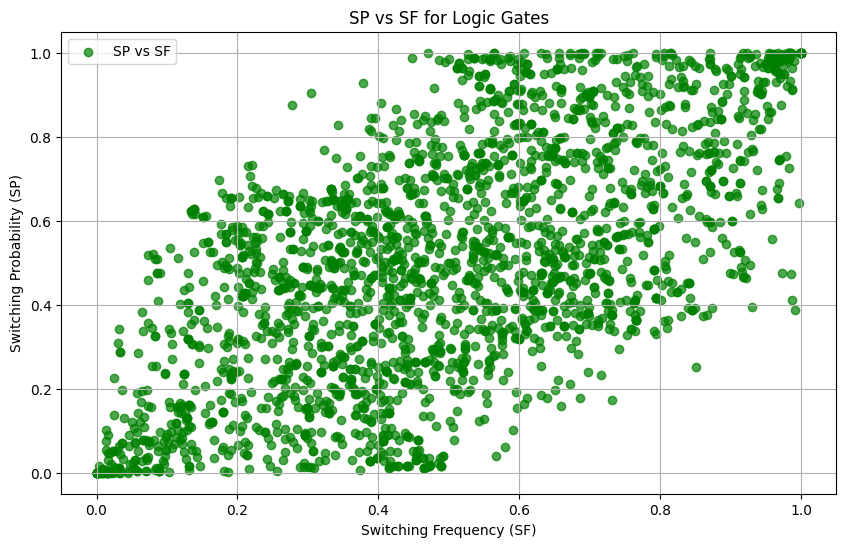

In [74]:
# (2) we should plot the SP values of the logic gates against the SF values of the same logic gates. This should be nearly linear.
def plot_sp_vs_sf(gate_dict, dict_size=2500):
    sp_values = []
    sf_values = []
    
    # Iterate through the gates in the dictionary
    for j in range(dict_size):
        gate = gate_dict.get(f'Gate {j+1}')
        
        if gate:
            # Extract SP and SF values for the current gate
            sp = gate.get('Switching Probability (prob_z)', 0)  # SP value (Switching Probability)
            sf = gate.get('Switching Frequency', 0)     # SF value (Switching Frequency)
            
            # Add values to the lists
            sp_values.append(sp)
            sf_values.append(sf)
    
    # Plot SP values against SF values
    plt.figure(figsize=(10, 6))
    plt.scatter(sf_values, sp_values, color='green', alpha=0.7, label='SP vs SF')
    
    # Adding a line of best fit (optional, for visual reference)
    #plt.plot(sf_values, sp_values, color='red', label='Line of Best Fit')
    
    plt.title('SP vs SF for Logic Gates')
    plt.xlabel('Switching Frequency (SF)')
    plt.ylabel('Switching Probability (SP)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sp_vs_sf(gate_prob_dict)

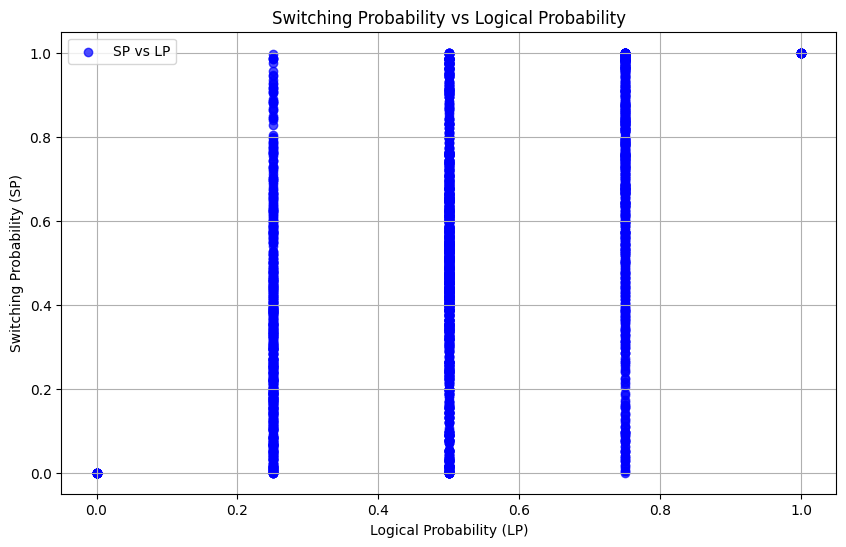

In [81]:
# (3) we should plot the SP values of the logic gates against the LP (signal probability) values of the same logic gates. 
# This should be nearly linear, but have some anomalous data groupings above or below the linear line.
def plot_sp_vs_lp(gate_dict):
    sp_values = []
    lp_values = []
    
    # Extract SP and LP values for each gate
    for gate_info in gate_dict.values():
        sp = gate_info.get('Switching Probability (prob_z)', 0)  # Default to 0 if not found
        lp = gate_info.get('Logic Probability', 0)  # Default to 0 if not found
        
        sp_values.append(sp)
        lp_values.append(lp)
    
    # Create the scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(lp_values, sp_values, color='blue', alpha=0.7, label='SP vs LP')
    
    # Optional: add a line of best fit
    # z = np.polyfit(lp_values, sp_values, 1)
    # p = np.poly1d(z)
    # plt.plot(lp_values, p(lp_values), "r--", label='Line of Best Fit')
    
    # Highlighting potential anomalies with different color or marker
    #for x, y in zip(lp_values, sp_values):
        #if abs(y - p(x)) > 0.1:  # threshold for considering a point as an anomaly
            #plt.scatter(x, y, color='red')
    
    plt.title('Switching Probability vs Logical Probability')
    plt.xlabel('Logical Probability (LP)')
    plt.ylabel('Switching Probability (SP)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_sp_vs_lp(gate_prob_dict)

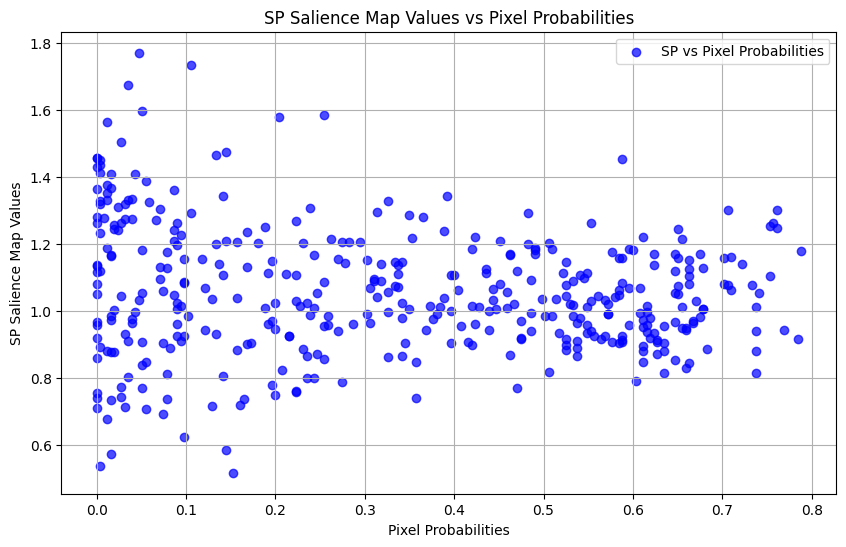

In [67]:
# (?) Plotting the SG against the Pixel Probabilities, does not give any meaning

def plot_sg_vs_prob(sg_per_pixel, pixel_probabilities):
    plt.figure(figsize=(10, 6))
    
    # Plot SP salience map values against pixel probabilities
    plt.scatter(pixel_probabilities, sg_per_pixel, color='blue', label='SP vs Pixel Probabilities', alpha=0.7)
    
    # Adding a line of best fit (linear regression)
    #plt.plot(pixel_probabilities, sg_per_pixel, color='red', label='Line of Best Fit')
    
    plt.title('SP Salience Map Values vs Pixel Probabilities')
    plt.xlabel('Pixel Probabilities')
    plt.ylabel('SP Salience Map Values')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_sg_vs_prob(np.array(sg_per_pixel).reshape(20,20), mnist_prob_map)

##### Switching Probability Visualizations

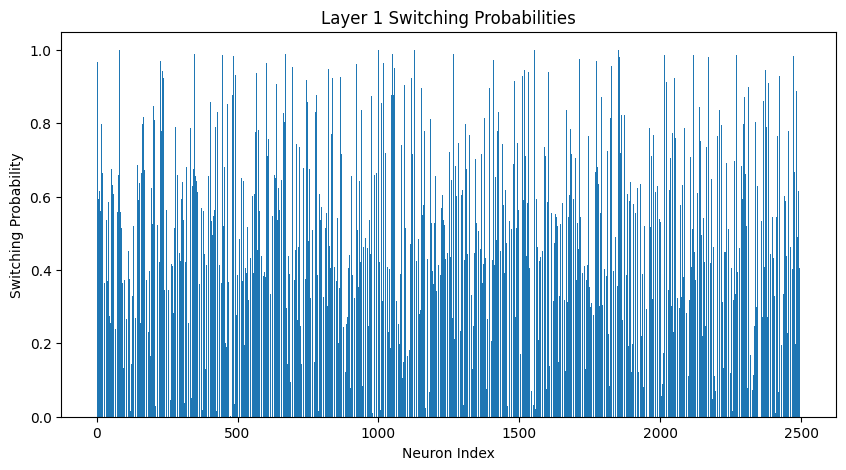

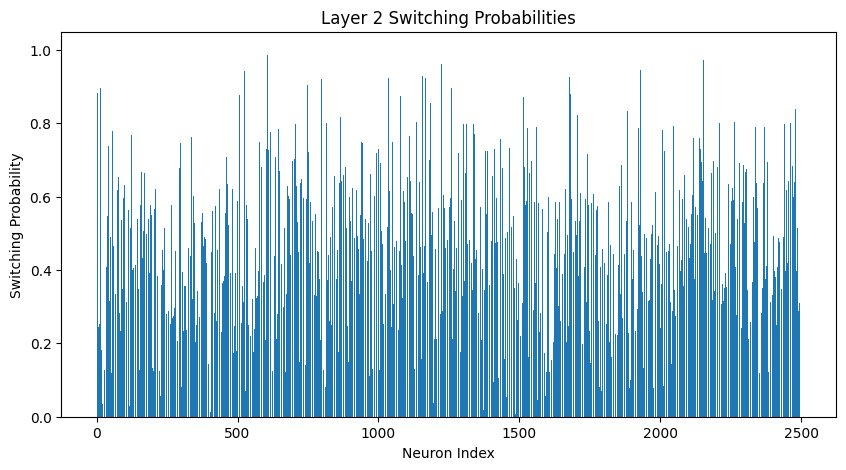

In [148]:
def visualize_switching_probabilities(switching_probs):
    """
    Plots switching probabilities across layers as a bar chart or heatmap.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(probs)), probs)
        plt.title(f"Layer {idx + 1} Switching Probabilities")
        plt.xlabel("Neuron Index")
        plt.ylabel("Switching Probability")
        plt.show()

visualize_switching_probabilities(switching_probs)

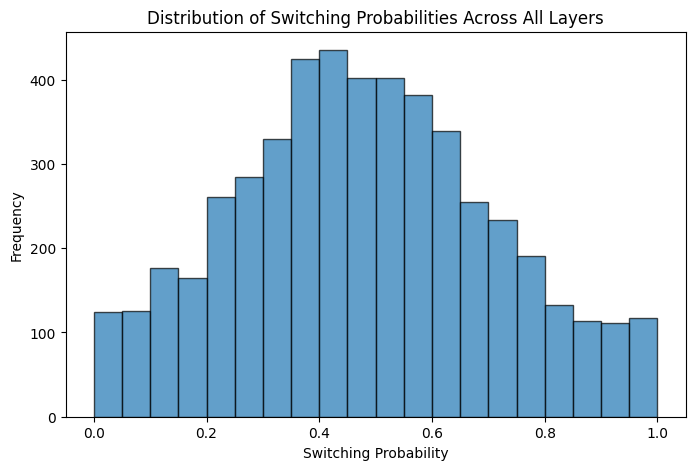

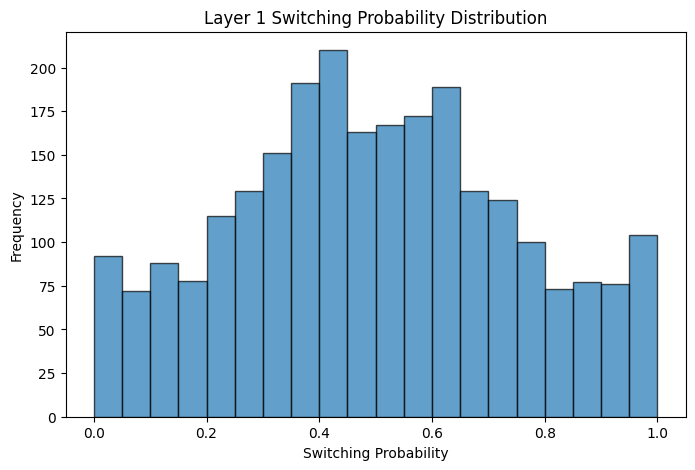

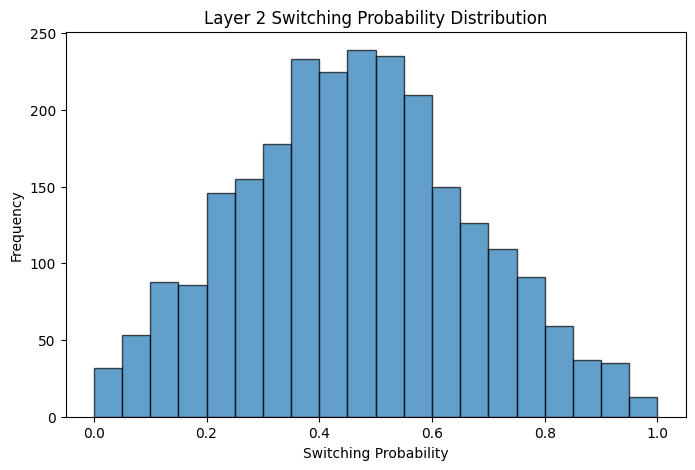

In [138]:
import matplotlib.pyplot as plt

def visualize_switching_probabilities(switching_probs):
    """
    Plots the distribution of switching probabilities across layers using histograms.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    # Flatten all switching probabilities into a single list to plot the overall distribution
    all_probs = [prob for layer_probs in switching_probs for prob in layer_probs]

    # Plot the distribution of switching probabilities for all layers
    plt.figure(figsize=(8, 5))
    plt.hist(all_probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    plt.title("Distribution of Switching Probabilities Across All Layers")
    plt.xlabel("Switching Probability")
    plt.ylabel("Frequency")
    plt.show()

    # Plot histograms for each layer
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Layer {idx + 1} Switching Probability Distribution")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

# Example usage
visualize_switching_probabilities(switching_probs)

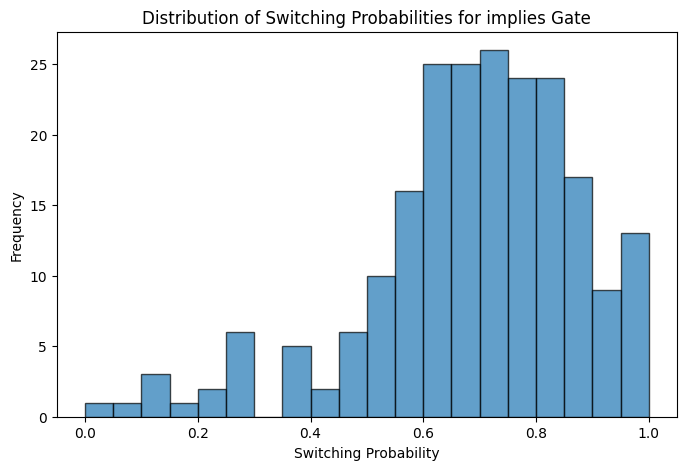

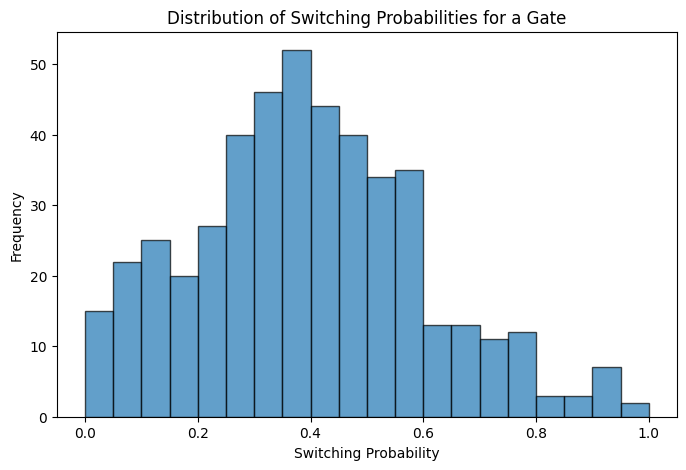

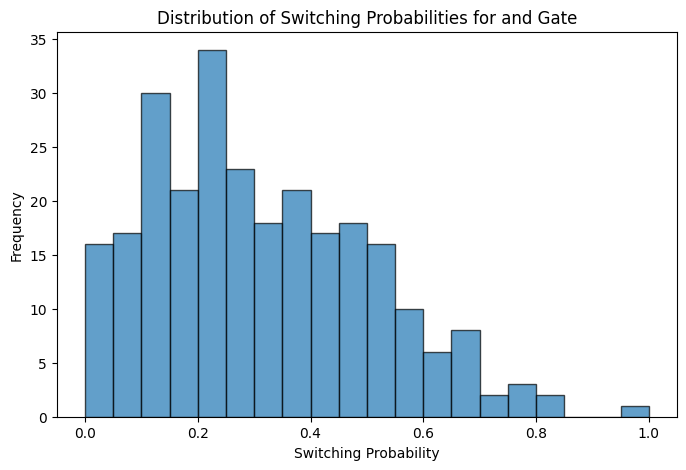

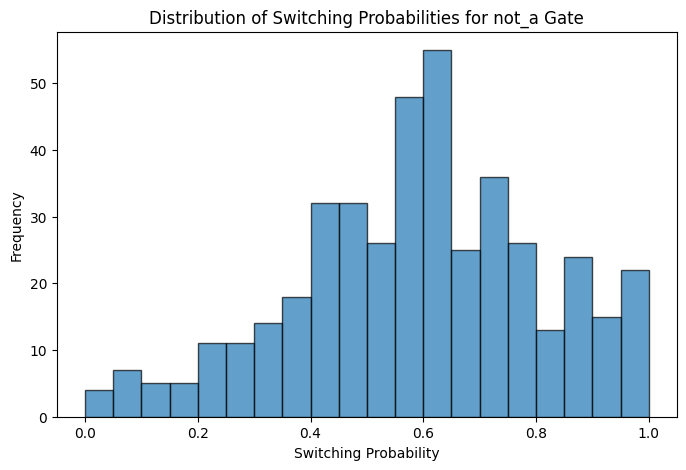

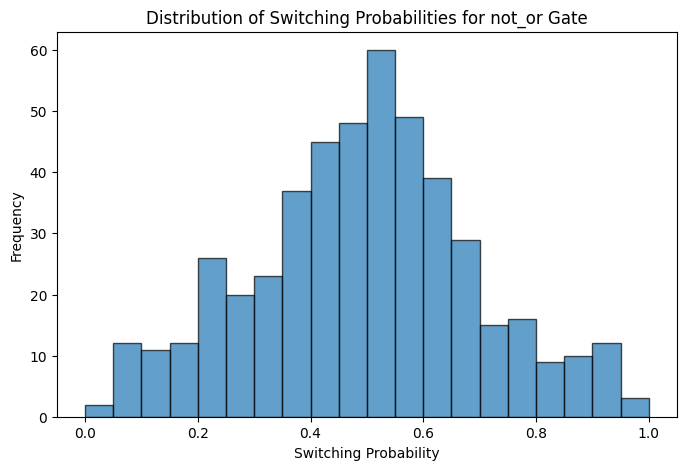

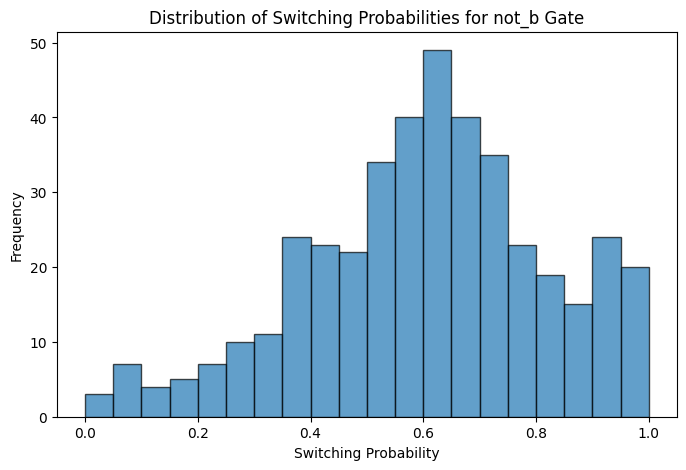

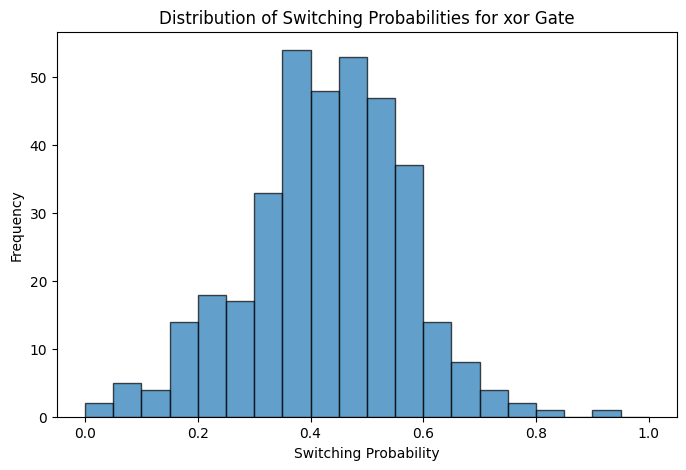

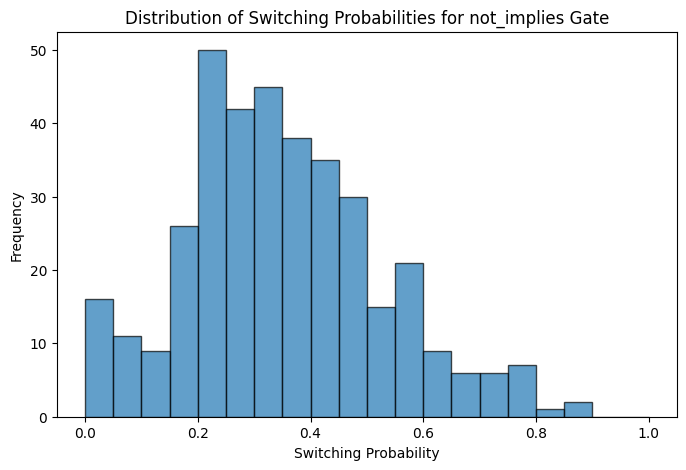

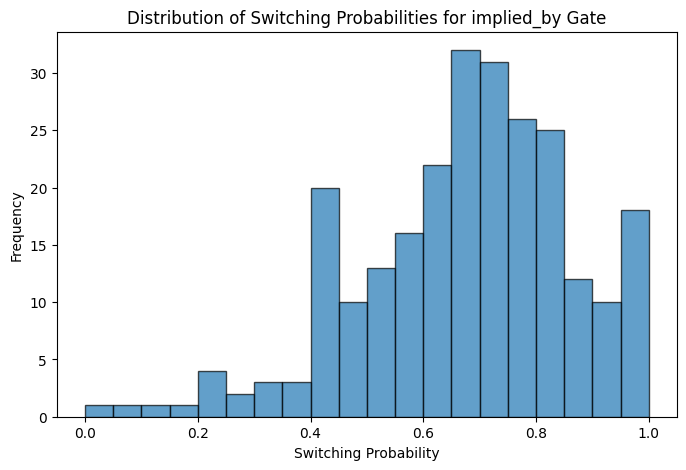

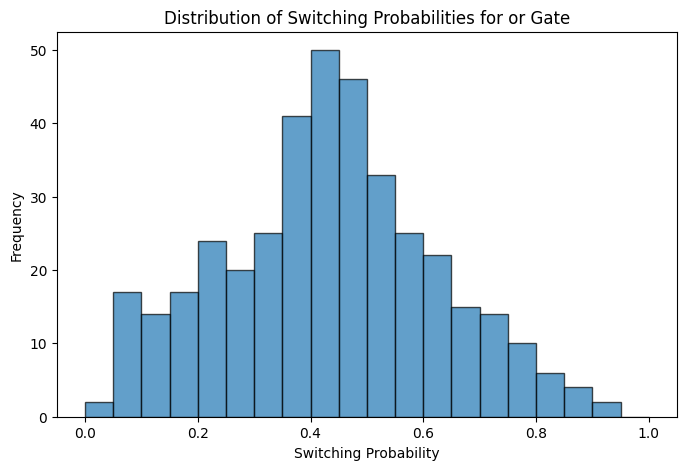

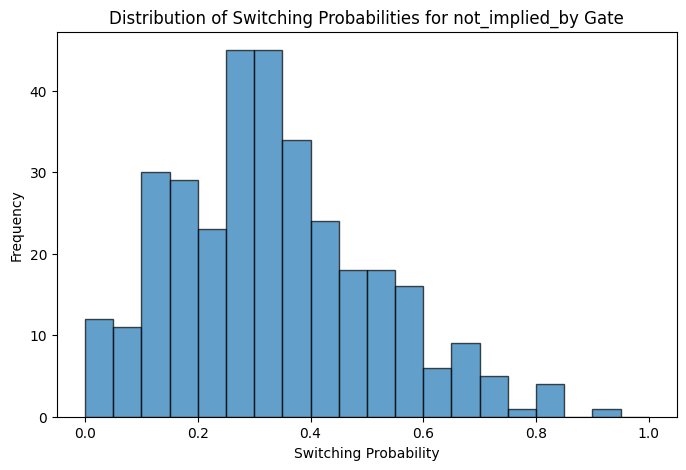

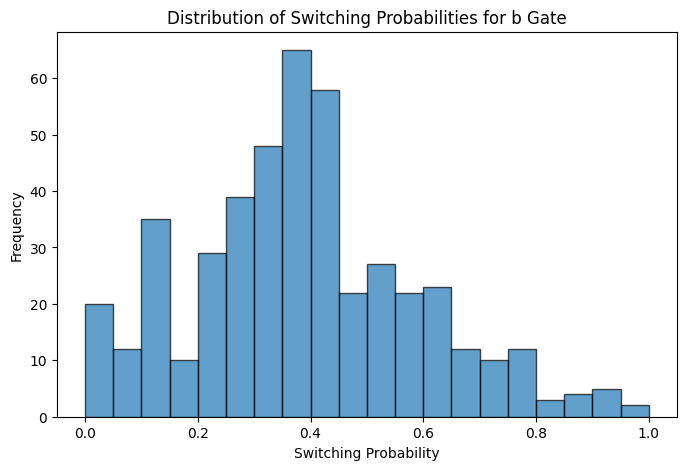

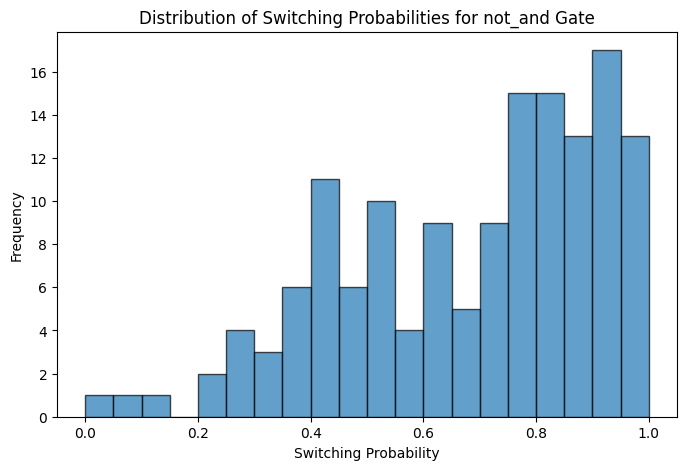

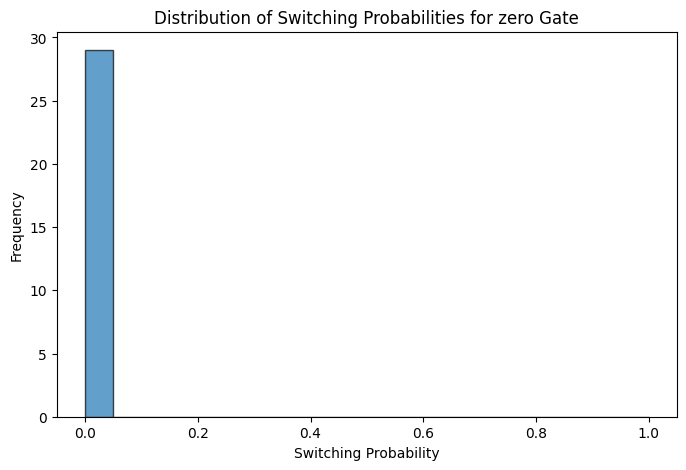

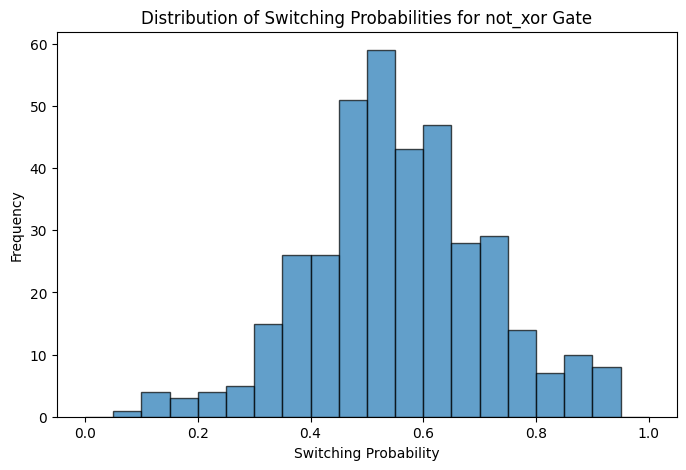

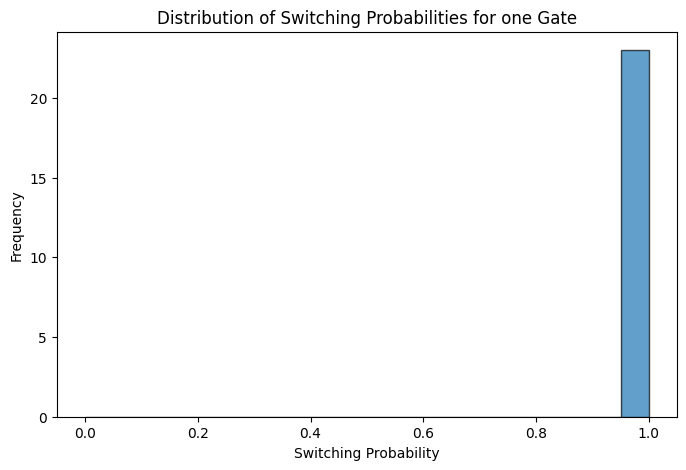

In [139]:
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_switching_probabilities_by_gate(gate_prob_dict_per_layer):
    """
    Plots the distribution of switching probabilities for each learned gate across layers using histograms.
    
    Args:
        gate_prob_dict_per_layer: A list of dictionaries per layer, each containing the learned gate and its switching probability for neurons in that layer.
    """
    # Dictionary to hold switching probabilities grouped by gate type
    gate_switching_probs = defaultdict(list)

    # Collect switching probabilities for each gate type across layers
    for layer_dict in gate_prob_dict_per_layer:
        for gate_key, gate_data in layer_dict.items():
            gate_type = gate_data['Learned Gate']  # The gate type (e.g., AND, OR, etc.)
            switching_prob = gate_data['Switching Probability']  # The switching probability for this neuron

            # Append the switching probability to the corresponding gate type
            gate_switching_probs[gate_type].append(switching_prob)

    # Plot the distribution of switching probabilities for each gate type
    for gate_type, probs in gate_switching_probs.items():
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Distribution of Switching Probabilities for {gate_type} Gate")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

# Example usage with the output of your get_gate_switching_probs function
visualize_switching_probabilities_by_gate(gate_switching_probs)

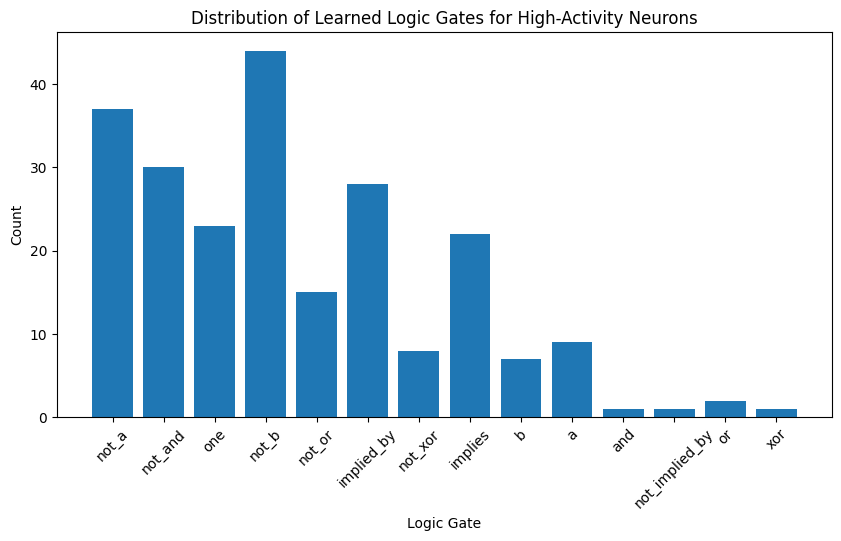

In [143]:
def get_high_activity_neurons(gate_switching_probs, threshold=0.5):
    """
    Finds neurons with switching probability greater than a threshold, and their associated logic gates.
    
    Args:
        gate_switching_probs: Output from get_gate_switching_probs.
        threshold: Switching probability threshold to consider a neuron as high-activity.

    Returns:
        high_activity_neurons: A dictionary with layer, neuron index, learned gate, inputs, and switching probability.
    """
    high_activity_neurons = []

    for layer_idx, gates in enumerate(gate_switching_probs):
        for neuron_idx, gate_info in gates.items():
            if gate_info["Switching Probability"] >= threshold:
                high_activity_neurons.append({
                    "Layer": layer_idx + 1,
                    "Neuron": neuron_idx,
                    "Gate": gate_info["Learned Gate"],
                    "Inputs": gate_info["Inputs"],
                    "Switching Probability": gate_info["Switching Probability"]
                })
    
    return high_activity_neurons

high_activity_neurons = get_high_activity_neurons(gate_switching_probs, threshold=0.9)
# print(high_activity_neurons)

from collections import Counter

def visualize_gate_distribution(high_activity_neurons):
    """
    Plots a bar chart showing the distribution of learned logic gates for high-activity neurons.
    
    Args:
        high_activity_neurons: Output from get_high_activity_neurons.
    """
    # Count gate occurrences
    gate_counter = Counter([neuron["Gate"] for neuron in high_activity_neurons])
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(gate_counter.keys(), gate_counter.values())
    plt.title("Distribution of Learned Logic Gates for High-Activity Neurons")
    plt.xlabel("Logic Gate")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Example usage:
visualize_gate_distribution(high_activity_neurons)

In [ ]:
ALL_OPERATIONS_PROBS = {
    "zero": 0.00,            # Always 0
    "and": 0.25,             # Only 11 switches it on
    "not_implies": 0.25,     # Only 10 switches it off
    "a": 0.50,               # 10, 11 switch it on
    "not_implied_by": 0.25,  # Only 01 switches it off
    "b": 0.50,               # 01, 11 switch it on
    "xor": 0.50,             # 01, 10 switch it on
    "or": 0.75,              # 01, 10, 11 switch it on
    "not_or": 0.25,          # Only 00 switches it off
    "not_xor": 0.50,         # 01, 10 switch it off
    "not_b": 0.50,           # 01, 11 switch it off
    "implied_by": 0.75,      # 00, 10, 11 switch it on
    "not_a": 0.50,           # 10, 11 switch it off
    "implies": 0.75,         # 00, 01, 11 switch it on
    "not_and": 0.75,         # Only 11 switches it off
    "one": 1.00              # Always 1
}

### All Models

#### Training

In [12]:
all_models_dict = {}
num_epochs = 150
file_path = 'trained_models/20x20_binary'

# Initialize Hydra with the config path and job name
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20_model077")

for model_name, model_cfg in cfg.models.items():
    print(f'training model {model_name}')

    # Initialize the dictionary entry for the model with an empty list for losses and other features
    all_models_dict[model_name] = {
        'losses': [],
        # Add other features here, e.g., 'accuracy': [], 'other_feature': []
    }

    try:
        # Initialize the model
        model = Model(model_cfg).to('cuda')
        optimizer = model.optimizer  
        
        # Initialize EarlyStopper for each model
        early_stopper = EarlyStopper(patience=5)  # Adjust patience as needed

        for epoch in range(num_epochs):
            loop = tqdm(train_loader, leave=True, desc=f'Epoch {epoch+1}/{num_epochs}')
            epoch_loss = 0  # Track the loss for the epoch
            
            for batch_inputs, batch_outputs in loop:
                # Move to GPU if available
                batch_inputs, batch_outputs = batch_inputs.to('cuda').double(), batch_outputs.to('cuda').long()

                # Create prediction dictionary
                prediction_dict = {
                    "input_data": batch_inputs, 
                    "true_output_data": batch_outputs
                }

                # Forward pass
                model.forward(prediction_dict)

                # Compute the loss
                loss = model.test_train(prediction_dict)

                # Zero gradients, backpropagate, and update the model parameters
                model.optimizer.zero_grad()
                loss.backward()
                model.step()
                
                # Accumulate loss for the epoch
                epoch_loss += loss.item()

            # Calculate average loss for the epoch
            epoch_loss /= len(train_loader)
            all_models_dict[model_name]['losses'].append(epoch_loss)
            print(f'Epoch {epoch+1} Loss: {epoch_loss}')

            # Check for early stopping
            if early_stopper.should_stop(epoch_loss):
                print(f"Early stopping triggered for {model_name} at epoch {epoch+1}.")
                break

        # Save the model after training completes
        FILE_NAME = f'{model_name}_weights'
        model.save(file_path, FILE_NAME)
        
        # Save the trained model metadata
        # save_model_state(model, optimizer, model_cfg, all_models_dict, metadata_file_path, model_name, num_epochs, batch_size)        
    
    except Exception as e:
        print(f"ERROR TRAINING {model_name.upper()}: {str(e)}")

print("All models processed.")

training model model_000
LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)


Epoch 1/150: 100%|██████████| 211/211 [00:15<00:00, 13.57it/s]


Epoch 1 Loss: 1.4539329826142697


Epoch 2/150: 100%|██████████| 211/211 [00:11<00:00, 19.15it/s]


Epoch 2 Loss: 0.6218096257797753


...

Epoch 63 Loss: 0.774049935157256
EarlyStopper Triggered:  3


Epoch 64/150: 100%|██████████| 211/211 [00:14<00:00, 14.42it/s]


Epoch 64 Loss: 0.7741714314995477
EarlyStopper Triggered:  4


Epoch 65/150: 100%|██████████| 211/211 [00:11<00:00, 18.28it/s]


Epoch 65 Loss: 0.774145951200699
EarlyStopper Triggered:  5
Early stopping triggered for model_009 at epoch 65.
All models processed.


#### Inference

In [23]:
trained_models_dir = 'trained_models/20x20_binary'


# Get a list of all model files in the directory
model_files = sorted([f for f in os.listdir(trained_models_dir) if f.endswith('.pth')])

with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20_model077")

# Loop through all model files and calculate their accuracies
for model_file in model_files:
    if model_file.endswith('_weights.pth'):
        model_name = model_file.removesuffix('_weights.pth')
    else:
        model_name = model_file.removesuffix('.pth')
    
    model_cfg = cfg['models'][model_name]
    
    # instantiate the model and load its weights
    model = Model(model_cfg).to('cuda')
    
    model_path = os.path.join(trained_models_dir, model_file)
    print(f"Evaluating {model_file}...")

    # Load the model
    model.load(model_path)

    # Calculate accuracy
    accuracy = model.get_accuracy(test_loader)
    
    print(f"Accuracy of {model_file}: {accuracy * 100:.2f}%\n")

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Evaluating model_000_weights.pth...


Running Inference: 100%|██████████| 34/34 [00:05<00:00,  6.56it/s]


Accuracy of model_000_weights.pth: 92.07%

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Evaluating model_001_weights.pth...


Running Inference: 100%|██████████| 34/34 [00:02<00:00, 14.24it/s]


Accuracy of model_001_weights.pth: 91.96%

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Evaluating model_002_weights.pth...


...

Accuracy of model_007_weights.pth: 90.13%

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Evaluating model_008_weights.pth...


Running Inference: 100%|██████████| 34/34 [00:01<00:00, 19.93it/s]


Accuracy of model_008_weights.pth: 88.73%

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Evaluating model_009_weights.pth...


Running Inference: 100%|██████████| 34/34 [00:01<00:00, 20.03it/s]

Accuracy of model_009_weights.pth: 87.01%



#### Graph Generation

In [13]:
import os
import torch
import matplotlib.pyplot as plt
import yaml
import numpy as np

# Helper function to compute the number of parameters in the model
def get_model_size(model):
    return sum(p.numel() for p in model.parameters())

# Helper function to count the number of layers in a model
def get_number_of_layers(model_cfg):
    return len(model_cfg['layers_config'])

# Path to the trained models and config file
trained_models_dir = 'trained_models'
config_file_path = 'config/mnist_config_20x20.yaml'

# Load the config file
with open(config_file_path, 'r') as file:
    config = yaml.safe_load(file)

In [15]:
# Get a list of all model files in the directory
model_files = sorted([f for f in os.listdir(trained_models_dir) if f.endswith('.pth')])

# Initialize lists to store results
model_names = []
accuracies = []
model_sizes = []
num_layers = []
learning_rates = []
input_dims = []

# Loop through all models
for model_file in model_files:
    if model_file.endswith('_weights.pth'):
        model_name = model_file.removesuffix('_weights.pth')
        model_cfg = config['models'][model_name]

        # instantiate the model and load its weights
        model = Model(model_cfg).to('cuda')
        model_path = os.path.join(trained_models_dir, model_file)
        model.load(model_path)

        # Calculate accuracy
        accuracy = model.get_accuracy(test_loader)

        # Collect model info
        model_names.append(model_name)
        accuracies.append(accuracy * 100)  # Store accuracy as percentage
        model_sizes.append(get_model_size(model))
        num_layers.append(get_number_of_layers(model_cfg))
        learning_rates.append(model_cfg['learning_rate'])
        input_dims.append(model_cfg['input_dim'])

LogicLayer(400, 100000, train)


Running Inference: 100%|██████████| 39/39 [00:01<00:00, 20.03it/s]


LogicLayer(400, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)
LogicLayer(20000, 20000, train)


Running Inference: 100%|██████████| 39/39 [00:01<00:00, 21.40it/s]


LogicLayer(400, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)
LogicLayer(10000, 10000, train)


...

Running Inference: 100%|██████████| 39/39 [00:02<00:00, 19.42it/s]


LogicLayer(400, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(1000, 1000, train)
LogicLayer(

Running Inference: 100%|██████████| 39/39 [00:02<00:00, 17.95it/s]


LogicLayer(400, 50000, train)


Running Inference: 100%|██████████| 39/39 [00:01<00:00, 21.49it/s]


In [29]:
model_sizes

array([1600000, 1600000, 1600000, 1600000, 1600000,  800000,  800000,
        800000,  800000,  800000,  160000,  160000,  160000,  160000,
        158720,   80000,   80000,   80000,   80000,   79360, 1600000,
       1600000, 1600000, 1600000, 1600000,  800000,  800000,  800000,
        800000,  800000,  160000,  160000,  160000,  160000,  158720,
         80000,   80000,   80000,   80000,   79360, 1600000, 1600000,
       1600000, 1600000, 1600000,  800000,  800000,  800000,  800000,
        800000,  160000,  160000,  160000,  160000,  158720,   80000,
         80000,   80000,   80000,   79360, 1600000, 1600000, 1600000,
       1600000, 1600000,  800000,  800000,  800000,  800000,  800000,
        160000,  160000,  160000,  160000,  158720,   80000,   80000,
         80000,   80000,   79360, 1600000, 1600000, 1600000, 1600000,
       1600000,  800000,  800000,  800000,  800000,  800000,  160000,
        160000,  160000,  160000,  158720,   80000,   80000,   80000,
         80000,   79

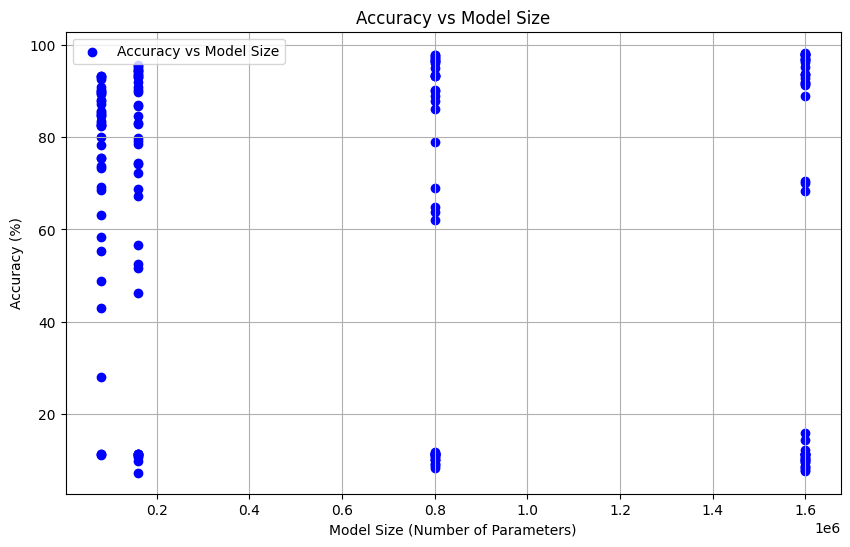

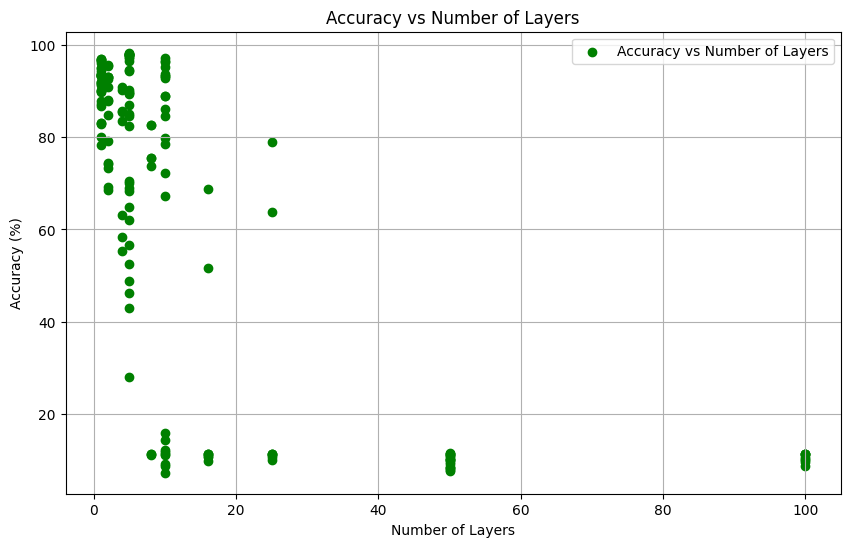

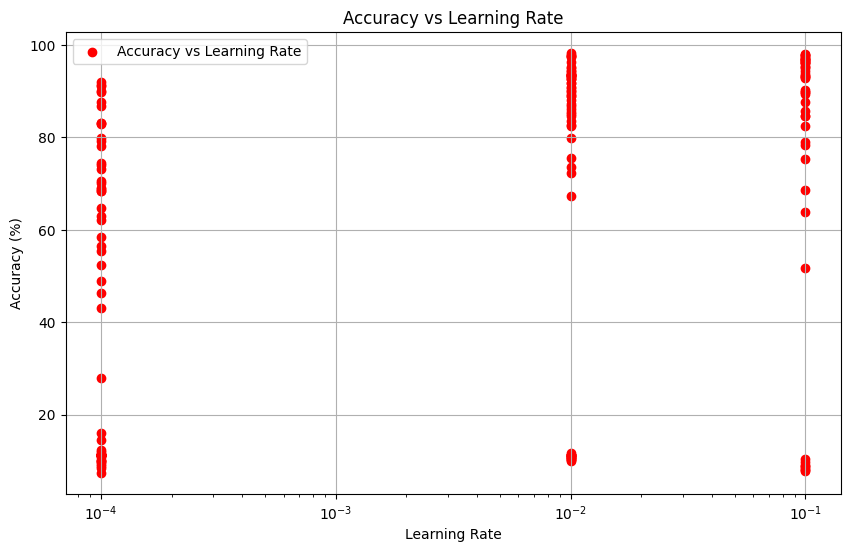

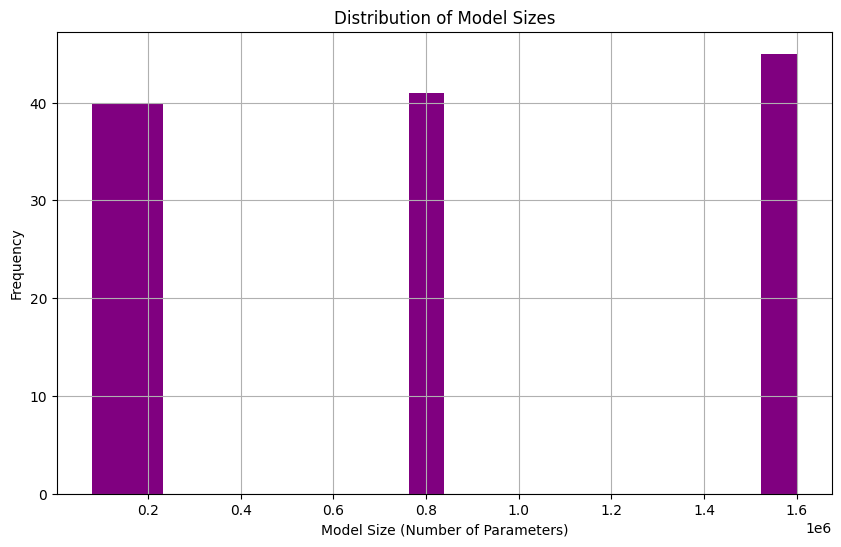

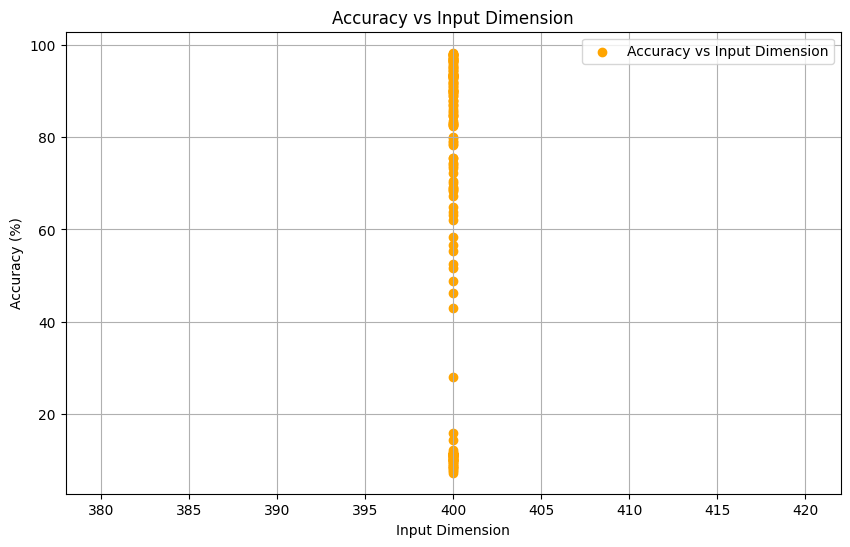

In [16]:
# Convert lists to numpy arrays for easier plotting
accuracies = np.array(accuracies)
model_sizes = np.array(model_sizes)
num_layers = np.array(num_layers)
learning_rates = np.array(learning_rates)
input_dims = np.array(input_dims)

# Plot Accuracy vs Model Size
plt.figure(figsize=(10, 6))
plt.scatter(model_sizes, accuracies, c='blue', label='Accuracy vs Model Size')
plt.title('Accuracy vs Model Size')
plt.xlabel('Model Size (Number of Parameters)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()

# Plot Accuracy vs Number of Layers
plt.figure(figsize=(10, 6))
plt.scatter(num_layers, accuracies, c='green', label='Accuracy vs Number of Layers')
plt.title('Accuracy vs Number of Layers')
plt.xlabel('Number of Layers')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()

# Plot Accuracy vs Learning Rate
plt.figure(figsize=(10, 6))
plt.scatter(learning_rates, accuracies, c='red', label='Accuracy vs Learning Rate')
plt.title('Accuracy vs Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy (%)')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

# Plot Model Size Distribution
plt.figure(figsize=(10, 6))
plt.hist(model_sizes, bins=20, color='purple')
plt.title('Distribution of Model Sizes')
plt.xlabel('Model Size (Number of Parameters)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

    # Bonus: Accuracy vs Input Dimension
plt.figure(figsize=(10, 6))
plt.scatter(input_dims, accuracies, c='orange', label='Accuracy vs Input Dimension')
plt.title('Accuracy vs Input Dimension')
plt.xlabel('Input Dimension')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Convert lists to numpy arrays for easier manipulation
accuracies = np.array(accuracies)
model_sizes = np.array(model_sizes)

# 1. Correlation Heatmap
# Create a DataFrame for easier analysis
import pandas as pd

data = {
    'Accuracy': accuracies,
    'Model Size': model_sizes,
    'Number of Layers': num_layers,
    'Learning Rate': learning_rates,
    'Input Dimension': input_dims
}

df = pd.DataFrame(data)

# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Model Parameters')
plt.show()

NameError: name 'accuracies' is not defined

#### Saving Metadata

In [17]:
total_num_neurons = sum(map(lambda x: x.num_neurons, logic_layers[1:-1]))
    print(f'total_num_neurons={total_num_neurons}')
    total_num_weights = sum(map(lambda x: x.num_weights, logic_layers[1:-1]))
    print(f'total_num_weights={total_num_weights}')
    if args.experiment_id is not None:
        results.store_results({
            'total_num_neurons': total_num_neurons,
            'total_num_weights': total_num_weights,
        })

IndentationError: unexpected indent (3607706656.py, line 2)

### Unused Code

In [ ]:
model_name = 'high_accuracy_model'
model_name_config = 'high_accuracy_model_config' # from mnist_config.yaml
model_name_weights = 'high_accuracy_model_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models' # directory where all trained model weights are saved
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]
model_cfg

loaded_model = Model(model_cfg).to('cuda')

if False:
    print("Weights after initializing but before loading:")
    for name, param in loaded_model.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection
            
accuracy = calculate_accuracy2(loaded_model, test_loader)
print(f"Accuracy of {model_name}: {accuracy * 100:.2f}%\n")

# instantiate the model and load its weights
loaded_model.load(PATH)
loaded_model.to('cuda')  # Ensure the model is on the GPU after loading weights

if False:
    print("Weights after loading:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection

accuracy = calculate_accuracy2(loaded_model, test_loader)
print(f"Accuracy of {model_name}: {accuracy * 100:.2f}%\n")

print("Weights before loading:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data[0]}")  # Print the first element of each layer's weights for inspection

loaded_model.diff_logic_model.eval()
def discretize_logic_gates(model):
    with torch.no_grad():  # Disable gradient tracking
        for layer in model.diff_logic_model.logic_layers:
            if hasattr(layer, "weights"):
                # Print the original weights shape for debugging
                print(f"Original weights shape: {layer.weights.shape}")

                # Get the indices of the maximum logic gate weights (discretization)
                hard_weights = torch.argmax(layer.weights, dim=-1)  # Shape: [64000]

                # Convert to one-hot encoding
                hard_weights_one_hot = torch.zeros_like(layer.weights)
                hard_weights_one_hot.scatter_(1, hard_weights.unsqueeze(-1), 1)

                # Replace the soft weights with the hard (discretized) one-hot encoded weights
                layer.weights.detach_().copy_(hard_weights_one_hot)
    return model
loaded_model = discretize_logic_gates(loaded_model)

# comparing the two models

model_state_dict = model.state_dict()
loaded_model_state_dict = loaded_model.state_dict()

# Check if all keys (parameters/buffers) match between the models
for key in model_state_dict.keys():
    if key not in loaded_model_state_dict:
        print(f"Key {key} is missing in loaded model.")
        continue
    
    # Compare the actual values of the parameters
    if not torch.allclose(model_state_dict[key], loaded_model_state_dict[key]):
        print(f"Mismatch found in key: {key}")
    else:
        print(f"Key {key} matches.")

# Check if there are any keys in loaded_model that are not in model
for key in loaded_model_state_dict.keys():
    if key not in model_state_dict:
        print(f"Extra key {key} found in loaded model.")
        
model_keys = set(model_state_dict.keys())
loaded_model_keys = set(loaded_model_state_dict.keys())

if model_keys != loaded_model_keys:
    print("Model architectures differ in keys:")
    print(f"Model keys: {model_keys - loaded_model_keys}")
    print(f"Loaded model keys: {loaded_model_keys - model_keys}")
else:
    print("Model architectures match.")

In [ ]:
# Change all 'connections': 'random' to 'connections': 'unique'
if False:
    for layer in model_cfg['layers_config'].values():
        if layer['connections'] == 'random':
            layer['connections'] = 'unique'

Old code to visualize switching probabilities

In [37]:
def get_average_switching_probs_first_layer(gate_switching_probs, num_pixels=400):
    """
    Calculates the average switching probability for each specific pixel (node) from the first layer in gate_switching_probs.
    
    Args:
        gate_switching_probs: List of dictionaries containing switching probabilities and inputs for each gate.
        num_pixels: The total number of nodes/pixels (default is 400 for a 20x20 image).
    
    Returns:
        avg_switching_probs: A list containing the average switching probability for each node.
    """
    # Initialize a dictionary to store the total switching probability and count for each pixel
    pixel_switching_data = {pixel: {"total_prob": 0, "count": 0} for pixel in range(num_pixels)}

    # Process only the first layer (gate_switching_probs[0])
    first_layer = gate_switching_probs

    # For each gate in the first layer, get the inputs (a and b) and their corresponding switching probabilities
    for gate, data in first_layer.items():
        a = data['a']  # First input node
        b = data['b']  # Second input node
        prob_a = data['prob_a']  # Switching probability for input a
        prob_b = data['prob_b']  # Switching probability for input b

        # Accumulate the switching probabilities for pixel 'a' if within bounds
        if 0 <= a < num_pixels:
            pixel_switching_data[a]['total_prob'] += prob_a
            pixel_switching_data[a]['count'] += 1
        else:
            print(f"Warning: Node 'a' with index {a} is out of bounds.")

        # Accumulate the switching probabilities for pixel 'b' if within bounds
        if 0 <= b < num_pixels:
            pixel_switching_data[b]['total_prob'] += prob_b
            pixel_switching_data[b]['count'] += 1
        else:
            print(f"Warning: Node 'b' with index {b} is out of bounds.")

    # Calculate the average switching probability for each pixel
    avg_switching_probs = []
    for pixel in range(num_pixels):
        total_prob = pixel_switching_data[pixel]['total_prob']
        count = pixel_switching_data[pixel]['count']
        # Avoid division by zero; if no activations, average is zero
        avg_prob = total_prob / count if count > 0 else 0
        avg_switching_probs.append(avg_prob)

    return avg_switching_probs

In [38]:
if small_mnist:
    num_pixels=400
else:
    num_pixels=784

average_switching_probs_first_layer = get_average_switching_probs_first_layer(gate_prob_dict, num_pixels)

#max(average_switching_probs_first_layer)

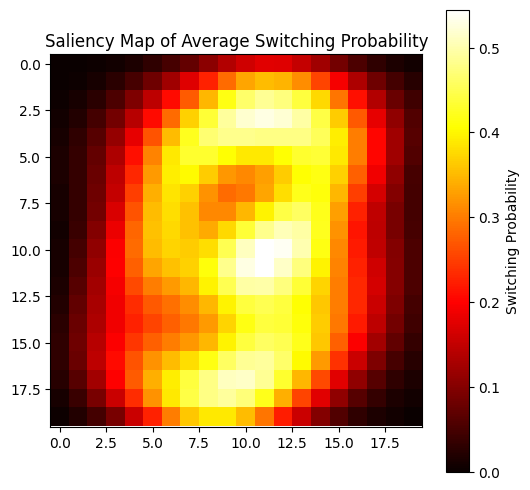

In [39]:
# Assume `average_switching_probs_first_layer` contains the 400 average switching probabilities for the first layer
saliency_map = np.reshape(average_switching_probs_first_layer, (20, 20))

# Plotting the saliency map
plt.figure(figsize=(6, 6))
plt.imshow(saliency_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Switching Probability')
plt.title('Saliency Map of Average Switching Probability')
plt.show()

##### Displays all models in config.yaml

In [ ]:
def func(model_cfg: DictConfig):
    working_dir = os.getcwd()
    #print(f"The current working directory is {working_dir}")

    # Access model-specific elements of the config
    print(f"The input dimension is {model_cfg.input_dim}")
    print(f"The learning rate is {model_cfg.learning_rate}")
    print(f"The Logic Layers are:")
    for layer_name in model_cfg.layers_config.items():
        print("\t", layer_name)

if __name__ == "__main__":
    # Initialize Hydra with the config path and job name
    with initialize(version_base=None, config_path="config", job_name="test_app"):
        cfg = compose(config_name="mnist_config_20x20")
        
    # Access all models in config.yaml
    for model_name, model_cfg in cfg.models.items():
        print(f"\n\nProcessing {model_name}")
        func(model_cfg)